# Análisis y Modelado de Series de Tiempo de Combustibles en Guatemala: Consumo, Importación y Precios (2000–2025)

Github: https://github.com/JosueSay/labs-ds
* Josue Say
* Flavio Galán

## Carga, limpieza y preparación de datos

1. Unificación de archivos
2. Selección de variables objetivo
3. Operaciones para unificar columnas
4. Estandarización de formatos (datetime y unidad en precios GQT/GAL)
5. Implementación de *caché* para leer los archivos de salida una vez que ya esten generados los posea el usuario


En caso de querer hacer el procedimiento de limpieza y unificación de datos se puede borrar el archivo `cache/df_cache.txt` este controla el proceso para hacer la unificación del proceso o leer unicamente los csv generados; si se desea usar los csv que ya se tienen estos siempre leeran los archivos de **data-ouput** y tranformando la columna "Fecha" a `DateTime` por lo que no es necesario validar, adicional el encabezado manejado, variables, control se encuentra en la sección de **Variables - Constantes**.

### Librerias

In [2]:
import pandas as pd
import numpy as np
import os

### Variables - Constantes

In [3]:
DATA_DIR = "./data-input"
OUTPUT_DIR = "./data-output"
REPORTES = "./reportes"
CACHE = "./cache"

# input files
CONSUMO_2024_XLSX = f"{DATA_DIR}/CONSUMO-HIDROCARBUROS-2024-12.xlsx"
CONSUMO_2025_XLSX = f"{DATA_DIR}/VENTAS-HIDROCARBUROS-2025-05.xlsx"
IMPORT_2024_XLSX = f"{DATA_DIR}/IMPORTACION-HIDROCARBUROS-VOLUMEN-2024-12.xlsx"
IMPORT_2025_XLSX = f"{DATA_DIR}/IMPORTACION-HIDROCARBUROS-VOLUMEN-2025-05.xlsx"
PRECIOS_2025_XLSX = f"{DATA_DIR}/Precios-Promedio-Nacionales-Diarios-2025-1.xlsx"

# output files
CONSUMO_CSV = f"{OUTPUT_DIR}/consumo_combustibles.csv"
IMPORT_CSV = f"{OUTPUT_DIR}/importacion_combustibles.csv"
PRECIOS_CSV = f"{OUTPUT_DIR}/precios_diarios.csv"
TARGET_COLUMNS = ["fecha", "regular", "superior", "diesel", "glp"]

# var control
SAVE_CONSUMO_CSV = True
SAVE_IMPORT_CSV = True
SAVE_PRECIOS_CSV = True
SAVE_REPORTES = True

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORTES, exist_ok=True)
os.makedirs(CACHE, exist_ok=True)

### Carga y conversión de archivos Excel a CSV

In [4]:
def loadAndProcessFuelData(file2024, file2025, saveCsv=False, outputCsvPath=None):
    # Load 2024 data
    df2024 = pd.read_excel(file2024, skiprows=6)
    df2024.columns = df2024.columns.str.strip().str.lower()
    print(f"2024 Data: {df2024.shape[0]} rows, {df2024.shape[1]} columns")

    # Drop last 3 rows
    df2024 = df2024.iloc[:-3]
    print("Removed unnecessary rows from 2024 data.")
    print(f"Updated 2024 Data: {df2024.shape[0]} rows, {df2024.shape[1]} columns")

    # Select and process columns
    target_col_2024 = [
        "fecha",
        "gas licuado de petróleo",
        "gasolina regular",
        "gasolina superior",
        "diesel alto azufre",
        "diesel bajo azufre"
    ]
    df2024 = df2024[target_col_2024]
    df2024["diesel bajo azufre"] = df2024["diesel bajo azufre"] + df2024["diesel alto azufre"]
    df2024 = df2024.drop(columns=["diesel alto azufre"])
    print("Processed 2024 columns.")

    # Load 2025 data
    df2025 = pd.read_excel(file2025, skiprows=6)
    df2025.columns = df2025.columns.str.strip().str.lower()
    print(f"2025 Data: {df2025.shape[0]} rows, {df2025.shape[1]} columns")

    # Drop last 3 rows
    df2025 = df2025.iloc[:-3]
    print("Removed unnecessary rows from 2025 data.")
    print(f"Updated 2025 Data: {df2025.shape[0]} rows, {df2025.shape[1]} columns")

    # Select target columns
    target_col_2025 = [
        "fecha",
        "gas licuado de petróleo",
        "gasolina regular",
        "gasolina superior",
        "diesel bajo azufre"
    ]
    df2025 = df2025[target_col_2025]
    print("Processed 2025 columns.")

    # Concatenate both years
    dfResult = pd.concat([df2024, df2025], ignore_index=True)
    print("Merged 2024 and 2025 data.")
    
    # Convert 'fecha' to datetime
    dfResult["fecha"] = pd.to_datetime(dfResult["fecha"])
    print("Converted 'fecha' column to datetime.")

    # Rename and reorder columns
    dfResult.rename(columns={
        "fecha": "fecha",
        "gasolina regular": "regular",
        "gasolina superior": "superior",
        "diesel bajo azufre": "diesel",
        "gas licuado de petróleo": "glp"
    }, inplace=True)

    dfResult = dfResult[TARGET_COLUMNS]

    # Save to CSV if requested
    if saveCsv and outputCsvPath:
        dfResult.to_csv(outputCsvPath, index=False)
        print(f"Data saved to {outputCsvPath}")

    return dfResult

In [5]:
def loadAndProcessMultipleSheets(configList, saveCsv=False, outputCsvPath=None):
    dfs = []

    for config in configList:
        filePath = config["filePath"]
        sheetName = config["sheetName"]
        skipRows = config["skipRows"]
        rowsToRemove = config["rowsToRemove"]

        # Leer hoja
        df = pd.read_excel(filePath, header=[0, 1], skiprows=skipRows, sheet_name=sheetName)
        print(f"Loaded sheet '{sheetName}': {df.shape[0]} rows")

        # Eliminar filas finales
        df = df.iloc[:-rowsToRemove]

        # Seleccionar columnas objetivo
        target_columns_multi = [
            ('FECHA', 'Unnamed: 0_level_1'),
            ('Regular', 'GTQ/GALON'),
            ('Superior', 'GTQ/GALON'),
            ('Diesel', 'GTQ/GALON'),
            ('Glp Cilindro 25Lbs.', 'GTQ/LB')
        ]
        df = df[target_columns_multi]

        # Aplanar nombres
        df.columns = [f"{col1.strip()}".lower() for col1, col2 in df.columns]

        # GLP conversión de GTQ/lb a GTQ/galón (25 lbs * 4.24)
        if 'glp cilindro 25lbs.' in df.columns:
            df['glp'] = df['glp cilindro 25lbs.'] * 4.24
            df.drop(columns=['glp cilindro 25lbs.'], inplace=True)
        else:
            df['glp'] = np.nan

        # Reordenar columnas finales
        df = df[TARGET_COLUMNS]

        print(f"Processed sheet '{sheetName}' with {df.shape[0]} rows")
        dfs.append(df)

    # Concatenar todo
    df_final = pd.concat(dfs, ignore_index=True)

    # Convertir y ordenar por fecha
    df_final["fecha"] = pd.to_datetime(df_final["fecha"])
    df_final = df_final.sort_values("fecha").reset_index(drop=True)
    print("Converted and sorted 'fecha' column.")

    # Guardar si aplica
    if saveCsv and outputCsvPath:
        df_final.to_csv(outputCsvPath, index=False)
        print(f"Final data saved to {outputCsvPath}")

    return df_final

In [6]:
def loadAllData():
    CACHE_FLAG = os.path.join(CACHE, "df_cache.txt")
    if not os.path.exists(CACHE_FLAG):
        configList = [
            {"filePath": PRECIOS_2025_XLSX, "sheetName": 0, "skipRows": 7, "rowsToRemove": 9},
            {"filePath": PRECIOS_2025_XLSX, "sheetName": 1, "skipRows": 7, "rowsToRemove": 2},
            {"filePath": PRECIOS_2025_XLSX, "sheetName": 2, "skipRows": 7, "rowsToRemove": 2},
            {"filePath": PRECIOS_2025_XLSX, "sheetName": 3, "skipRows": 6, "rowsToRemove": 2},
            {"filePath": PRECIOS_2025_XLSX, "sheetName": 4, "skipRows": 6, "rowsToRemove": 2}
        ]

        df_consumo = loadAndProcessFuelData(CONSUMO_2024_XLSX, CONSUMO_2025_XLSX, saveCsv=SAVE_CONSUMO_CSV, outputCsvPath=CONSUMO_CSV)
        df_importaciones = loadAndProcessFuelData(IMPORT_2024_XLSX, IMPORT_2025_XLSX, saveCsv=SAVE_IMPORT_CSV, outputCsvPath=IMPORT_CSV)

        df_precios = loadAndProcessMultipleSheets(
            configList=configList,
            saveCsv=SAVE_PRECIOS_CSV,
            outputCsvPath=PRECIOS_CSV
        )
        
        with open(CACHE_FLAG, "w") as f:
            f.write("cached")

        print("Procesamiento completado desde archivos fuente.")
    else:
        df_consumo = pd.read_csv(CONSUMO_CSV, parse_dates=["fecha"])
        df_importaciones = pd.read_csv(IMPORT_CSV, parse_dates=["fecha"])
        df_precios = pd.read_csv(PRECIOS_CSV, parse_dates=["fecha"])

        print("Datos cargados desde cache CSV.")
    return df_consumo, df_importaciones, df_precios

### Generación de reportes para explorar data

In [7]:
def generateBasicReport(df, name):
    report_path = os.path.join(REPORTES, f"{name}_reporte.txt")

    with open(report_path, "w", encoding="utf-8") as f:
        f.write("REPORTE BÁSICO DE DATAFRAME\n")
        f.write("=" * 40 + "\n\n")

        # Dimensiones
        f.write(f"Total filas: {df.shape[0]}\n")
        f.write(f"Total columnas: {df.shape[1]}\n\n")

        # Columnas
        f.write("Columnas:\n")
        for col in df.columns:
            f.write(f"  - {col}\n")
        f.write("\n")

        # Tipos de datos
        f.write("Tipos de datos por columna:\n")
        f.write(df.dtypes.to_string())
        f.write("\n\n")

        # Nulos
        f.write("Valores nulos por columna:\n")
        f.write(df.isnull().sum().to_string())
        f.write("\n\n")

        # Porcentaje de nulos
        f.write("Porcentaje de nulos por columna:\n")
        null_pct = (df.isnull().mean() * 100).round(2)
        f.write(null_pct.to_string())
        f.write("\n\n")

        # Duplicados
        f.write(f"Total filas duplicadas: {df.duplicated().sum()}\n\n")

        # Estadísticas básicas (numéricas)
        f.write("Estadísticas básicas (solo numéricas):\n")
        f.write(df.describe().to_string())
        f.write("\n\n")

        # Medianas
        f.write("Mediana por columna numérica:\n")
        f.write(df.median(numeric_only=True).to_string())
        f.write("\n")

    print(f"Reporte generado en: {report_path}")


In [8]:
if SAVE_REPORTES:
  df_consumo, df_importaciones, df_precios = loadAllData()
  generateBasicReport(df_consumo, "consumo_combustibles")
  generateBasicReport(df_importaciones, "importacion_combustibles")
  generateBasicReport(df_precios, "precios_combustibles")

Datos cargados desde cache CSV.
Reporte generado en: ./reportes\consumo_combustibles_reporte.txt
Reporte generado en: ./reportes\importacion_combustibles_reporte.txt
Reporte generado en: ./reportes\precios_combustibles_reporte.txt


## Análisis exploratorio

### Librerias

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

### Variables - Constantes

In [10]:
# Variables control para mostrar histogramas, series de tiempo, heatmaps y casos especiales (pandemia y reciente)
SHOW_ST = False
SHOW_HT = False
SHOW_HM = False
SHOW_SC = False

IMAGES_DIR = "./images"
HISTOGRAMA = os.path.join(IMAGES_DIR, "histogramas")
ST = os.path.join(IMAGES_DIR, "series_tiempo")
HM = os.path.join(IMAGES_DIR, "heatmap")
SC = os.path.join(IMAGES_DIR, "special_cases")

os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(HISTOGRAMA, exist_ok=True)
os.makedirs(ST, exist_ok=True)
os.makedirs(HM, exist_ok=True)
os.makedirs(SC, exist_ok=True)

### Preparación previa

In [11]:
df_consumo, df_importaciones, df_precios = loadAllData()
df_consumo.set_index('fecha', inplace=True)
df_importaciones.set_index('fecha', inplace=True)
df_precios.set_index('fecha', inplace=True)

Datos cargados desde cache CSV.


### Resumen Estadístico

Entre los años 2000 y 2025, el diésel ha sido el combustible más consumido en Guatemala, seguido por gasolina superior, regular y finalmente GLP, cuyo menor uso se asocia a su destino doméstico y menor presencia en el transporte. Las importaciones reflejan este mismo patrón, aunque el GLP muestra una mediana alta, lo que indica su creciente relevancia. En cuanto a precios (2021–2025), la gasolina superior y regular son las más caras, el diésel presenta alta volatilidad, y el GLP mantiene precios más bajos y estables.

#### Consumo

Estos tienen un rango en los años 2000 hasta 2025, dada la descripción de las medidas se puede observar que:

* **Diésel** es el combustible más consumido (media ≈ 880,197 barriles mensuales), seguido de superior y regular.
* **GLP** presenta menor consumo relativo puede deberse a que su uso principal no puede ser a vehículos y este combustible compite con otros más usados en Guatemala.

Si detallamos los datos observados:

| Combustible | Promedio (barriles) | Mínimo  | Máximo    | Observaciones clave                                               |
| ----------- | ------------------- | ------- | --------- | ----------------------------------------------------------------- |
| Regular     | 405,017             | 160,742 | 942,394   | Alta dispersión. Consumo se ha más que duplicado desde el mínimo. |
| Superior    | 474,466             | 300,243 | 790,948   | Menor varianza relativa que la regular.                           |
| Diésel      | 880,198             | 507,663 | 1,474,651 | El más consumido con diferencia.                                  |
| GLP         | 322,886             | 167,818 | 600,454   | Menor consumo.                                                    |

**Comentario:** El diésel lidera en consumo total, lo cual refleja el papel del transporte pesado en Guatemala. El GLP, aunque menor en volumen, es clave para el uso doméstico. La gasolina superior tiene menor varianza que la regular, indicando una demanda más estable.

#### Importación

Estos datos tienen un rango en los años 2001 hasta 2025, dada la descripción de las medidas se puede observar que:

* **Patrón similar al consumo:** diésel > superior > regular > GLP.
* **GLP** muestra una mediana alta (\~416,000 barriles), indicando su importancia creciente.

Si detallamos los datos observados:

| Combustible | Promedio (barriles) | Mínimo  | Máximo    | Observaciones clave                           |
| ----------- | ------------------- | ------- | --------- | --------------------------------------------- |
| Regular     | 419,996             | 81,015  | 1,141,366 | Alta variabilidad.                            |
| Superior    | 494,588             | 170,293 | 1,227,174 | Similar a la regular, pero con mayor volumen. |
| Diésel      | 899,561             | 229,765 | 1,617,427 | Confirma alta dependencia.                    |
| GLP         | 422,204             | 100,562 | 1,077,123 | Muy variable, picos fuertes.                  |

**Comentario:** Las importaciones de diésel y GLP muestran grandes picos, lo cual sugiere eventos de demanda extraordinaria o cambios en política de abastecimiento.

#### Precios

Estos datos tienen un rango en los años 2021 hasta 2025, dada la descripción de las medidas se puede observar que:

* **Super y regular** son los más caros (medianas: Q32.19 y Q30.78).
* **GLP**, mantiene precios más bajos (mediana ≈ Q20.35).
* **Diésel** tiene amplia variación (de Q17.61 a Q41.27), reflejando impacto de precios internacionales.
* Precios muestran una tendencia creciente (máximos en 2025), aún se desconoce el motivo.

Si detallamos los datos observados:

| Combustible | Mediana (Q/galón) | Rango Intercuartílico | Máximo | Observaciones clave                                |
| ----------- | ----------------- | --------------------- | ------ | -------------------------------------------------- |
| Regular     | Q30.78            | Q28.28 – Q33.28       | Q40.50 | Aumentos significativos post-2022.                 |
| Superior    | Q32.19            | Q29.51 – Q34.52       | Q43.24 | Precio más alto, pero sigue patrón de la regular.  |
| Diésel      | Q27.73            | Q25.44 – Q31.30       | Q41.27 | Más volátil. Alta subida en eventos críticos.      |
| GLP (25 lb) | Q20.35            | Q19.50 – Q20.69       | Q24.93 | Más estable, pero con picos.                       |

**Comentario:** Los precios muestran incrementos claros desde 2021, probablemente relacionados con la pandemia, crisis de suministro global y guerra Rusia-Ucrania. GLP es el más controlado.

In [12]:
print("Resumen consumo:\n", df_consumo.describe())
print("\nResumen importaciones:\n", df_importaciones.describe())
print("\nResumen precios:\n", df_precios.describe())

Resumen consumo:
              regular       superior        diesel            glp
count     305.000000     305.000000  3.050000e+02     305.000000
mean   405016.802384  474465.500605  8.801976e+05  322885.822617
std    225100.212304  117354.116627  2.319830e+05  118981.768608
min    160741.900000  300242.781667  5.076627e+05  167818.137897
25%    216560.790000  385044.965833  7.012555e+05  227154.969762
50%    290286.650000  424438.710000  8.076921e+05  268875.095238
75%    570267.250000  575720.920000  1.062409e+06  407953.780000
max    942394.340000  790948.040000  1.474651e+06  600453.870000

Resumen importaciones:
             regular      superior        diesel           glp
count  2.930000e+02  2.930000e+02  2.930000e+02  2.930000e+02
mean   4.199959e+05  4.945875e+05  8.995610e+05  4.222037e+05
std    2.471180e+05  1.578443e+05  2.945229e+05  2.059063e+05
min    8.101530e+04  1.702925e+05  2.297647e+05  1.005615e+05
25%    2.087960e+05  3.724865e+05  6.931605e+05  2.305846e+05


### Histogramas

El análisis de los histogramas revela que ninguna de las variables (consumo, importación o precios) sigue una distribución normal. En el caso del consumo e importación, se observa una fuerte asimetría positiva, especialmente en gasolina regular y GLP, con presencia de valores extremos que reflejan eventos puntuales de alta demanda. El diésel destaca por ser el más estable y con mayor volumen en ambas dimensiones, lo que lo convierte en un buen candidato para modelado directo. En cuanto a los precios, las gasolinas regular y superior presentan distribuciones más simétricas, mientras que el diésel muestra alta variabilidad, probablemente influenciada por factores externos. El GLP, por su parte, presenta una distribución escalonada, indicando posible regulación o control estatal. Estos patrones sugieren la necesidad de aplicar transformaciones en varias series para futuros modelos de predicción, especialmente aquellos basados en ARIMA.

#### Consumo

* Ninguna variable tiene distribución normal.
* Diésel es el más estable y con mayor volumen.
* Regular y GLP muestran mayor variabilidad y picos, útiles para análisis de impacto de eventos.
* Transformaciones serán necesarias en algunas variables para aplicar ARIMA.

##### Combustible regular

* **Distribución sesgada a la derecha** (asimetría positiva): la mayoría de los valores están entre 160,000 y 300,000 barriles.
* Hay **valores extremos** en los rangos altos (>600,000).
* **No es normal**, lo que implicaría necesidad de transformación o diferenciación en modelos futuros.

##### Combustible superior

* Presenta una concentración entre **380,000 y 450,000 barriles**, pero con una segunda “ola” más alta entre **600,000 y 700,000**.
* **Distribución bimodal**: sugiere que hubo dos periodos distintos de comportamiento.
* También muestra asimetría, aunque menos marcada que la regular.

##### Combustible diésel

* Tiene una forma más cercana a la normalidad, aunque ligeramente sesgada.
* La mayoría de valores caen entre **600,000 y 1,000,000 barriles**, con colas hacia ambos extremos.
* **Menor variabilidad relativa**, lo que lo hace un buen candidato para modelado directo.

##### Combustible GLP

* **Sesgo a la derecha** y múltiples picos (posible estacionalidad o políticas como subsidios).
* Agrupación fuerte entre **200,000 y 300,000**, pero también hay varios valores grandes.
* Esto sugiere comportamiento no lineal.

<div style="text-align: center;">
  <img src="./images/histogramas/consumo_histograma.png" alt="Histograma Consumos" height="500"/>
</div>

#### Importaciones

* Ninguna variable tiene distribución normal.
* **Diésel y GLP** muestran alta dispersión.
* La gasolina **regular** muestra la distribución más sesgada.
* Todas las series requerirán transformación o diferenciación para modelado ARIMA.

##### Combustible regular

* **Fuertemente sesgada a la derecha**: la mayoría de los valores se concentran entre **150,000 y 300,000 barriles**.
* Hay una **cola larga** de importaciones grandes (>600,000), indicando picos de importación posiblemente excepcionales.
* Esta variabilidad sugiere comportamiento no estacionario.

##### Combustible superior

* Tiene un patrón **más simétrico**, con una clara concentración entre **400,000 y 600,000 barriles**.
* Se observan algunos valores atípicos (outliers) por arriba del millón.
* Comparada con la regular, su distribución es más equilibrada y estable.

##### Combustible diésel

* Amplia dispersión y **ligera asimetría positiva**.
* Frecuencia mayor en el rango de **600,000 a 1,000,000 barriles**, pero con bastantes puntos en rangos más altos (>1,400,000).
* El comportamiento parece ser más **continuo** pero **con picos abruptos**, lo que hace que se deba verificar estacionalidad o eventos externos.

##### Combustible GLP

* **Distribución irregular**, con picos en varios rangos.
* Muestra varios **modos (picos locales)** entre **200,000 y 700,000**, lo cual puede estar relacionado con **cambios de demanda estacional o subsidios gubernamentales**.
* Requiere transformación para suavizar la varianza y detectar componentes estructurales.

<div style="text-align: center;">
  <img src="./images/histogramas/importaciones_histograma.png" alt="Histograma Importaciones" height="500"/>
</div>

#### Precios

* **Superior y regular** presentan comportamientos cercanos a la simetría.
* **GLP** tiene una distribución **discreta por bloques**, lo cual puede deberse a **precios fijos**.
* **Diésel** es el más disperso.
* Podrían usarse modelos sin transformación para los meses.

##### Gasolina regular

* Distribución **ligeramente sesgada a la derecha**.
* Concentración principal entre **Q27.5 y Q32.5 por galón**.
* Algunos valores extremos sobre Q38.

##### Gasolina superior

* Distribución **más simétrica**, con un **modo claro cerca de Q31–Q32**.
* Se extiende hasta Q43, pero la mayoría de observaciones están por debajo de Q36.
* Tiene una **forma de campana**, aunque con colas un poco más pesadas.

##### Combustible diésel

* **Distribución amplia**, cubriendo desde **Q19 hasta Q41**.
* Varios picos de frecuencia entre Q25 y Q30.
* Probablemente el más afectado por **volatilidad internacional** en precios.

##### Combustible GLP

* Distribución **discreta/escalonada**: se observan bloques definidos en niveles específicos (ej. Q20, Q21, Q22).
* Refleja posible **control de precios**.
* No sigue una distribución continua clásica.

<div style="text-align: center;">
  <img src="./images/histogramas/precios_histograma.png" alt="Histograma Precios" height="500"/>
</div>

In [13]:
for df, nombre in zip([df_consumo, df_importaciones, df_precios], 
                      ['consumo', 'importaciones', 'precios']):
    axes = df.hist(figsize=(10, 6), bins=30)

    for ax in axes.flatten():
        ax.tick_params(axis='both', labelsize=8)
        ax.xaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='scientific', axis='x', scilimits=(3, 5))
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(3, 5))
        ax.set_title(ax.get_title(), fontsize=9)
        ax.set_xlabel("Valor", fontsize=9)
        ax.set_ylabel("Frecuencia", fontsize=9)

    plt.suptitle(f'Distribución de variables - {nombre.capitalize()}', fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    path_salida = os.path.join(HISTOGRAMA, f"{nombre}_histograma.png")
    plt.savefig(path_salida, dpi=150)
    if SHOW_HT:
        plt.show()
    else:
        plt.close()

### Series de tiempo

Las series de tiempo de consumo, importaciones y precios reflejan tendencias crecientes sostenidas, interrumpidas por eventos externos como la pandemia en 2020 y choques de precios en 2022. El diésel domina en volumen, mientras que el GLP muestra un crecimiento reciente. Los precios son más volátiles y responden a factores internacionales. Hay indicios de estacionalidad y comportamientos estructurales distintos por tipo de combustible. Estas características sugieren la necesidad de transformaciones y pruebas de estacionariedad antes de aplicar modelos ARIMA.

#### Consumos

La serie temporal de consumo confirma el fuerte impacto de la **pandemia en 2020** y la recuperación sostenida desde entonces. El **diésel sigue siendo dominante**, mientras que GLP muestra un crecimiento más reciente pero constante. Regular y superior mantienen un comportamiento similar, con diferencias en volatilidad. Se evidencian **tendencias y posibles patrones estacionales**, lo que sugiere que el modelado ARIMA requerirá pruebas de estacionariedad y, posiblemente, descomposición de la serie.

* Todos los combustibles muestran una tendencia creciente a lo largo del tiempo, con un aumento más marcado a partir de 2017–2018.
* Se observa una caída abrupta en 2020 especialmente notoria en diésel y superior.
* Posterior a la caída, hay una recuperación acelerada hasta 2024, con máximos históricos en varios combustibles.
* Se aprecian patrones estacionales, principalmente en diésel y regular.

<div style="text-align: center;">
  <img src="./images/series_tiempo/consumo/consumo_combinada.png" alt="Serie de tiempo para consumos" height="500"/>
</div>


##### Combustible regular

* Estancada hasta 2010, y luego acelera su consumo a partir de 2015.
* Notoria caída en pandemia, seguida de repunte en 2021.
* Presenta alta variabilidad mensual, lo que sugiere cierta estacionalidad o sensibilidad al precio.

##### Combustible superior

* Tendencia estable hasta 2018, luego crecimiento moderado.
* Disminución clara en 2020, con recuperación posterior.
* Muestra menor dispersión que la regular, lo que valida lo observado en histogramas.

##### Combustible diésel

* Tendencia positiva clara desde 2000.
* Picos recurrentes que podrían deberse a demanda por transporte pesado.
* Impacto fuerte en 2020, con rápida recuperación posterior.

##### Combustible GLP

* Crecimiento constante, con una aceleración visible desde 2016.
* Caída en 2020 seguida de un ascenso continuo.
* Sin picos marcados estacionales, pero sí tendencia estructural creciente.

<table style="margin: auto; text-align: center; border-collapse: collapse; border: none;">
  <tr>
    <td style="border: none;">
      <img src="./images/series_tiempo/consumo/consumo_regular.png" alt="Consumo combustible regular" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/series_tiempo/consumo/consumo_superior.png" alt="Consumo combustible superior" height="280"/>
    </td>
  </tr>
  <tr>
    <td style="border: none;">
      <img src="./images/series_tiempo/consumo/consumo_diesel.png" alt="Consumo combustible diésel" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/series_tiempo/consumo/consumo_glp.png" alt="Consumo combustible GLP" height="280"/>
    </td>
  </tr>
</table>


#### Importaciones

La serie temporal de importaciones refleja un comportamiento **más volátil que el consumo**, con picos abruptos, especialmente en diésel y GLP. A pesar del ruido, también se identifica una tendencia creciente desde el año 2000. Se observa una caída durante la **pandemia en 2020**, seguida por una recuperación acelerada. Esto indica que, para modelado con ARIMA u otros enfoques, será necesario aplicar **suavizamiento, transformación o diferenciación** para estabilizar la varianza.

* Todas las series muestran incremento a lo largo del tiempo.
* Se identifican importaciones puntuales anormalmente altas.
* En 2020, se evidencia una caída generalizada, coincidente con la pandemia, seguida por una recuperación rápida hasta alcanzar niveles máximos en 2024.
* La alta variabilidad sugiere que factores externos que influyó en las exportaciones.

<div style="text-align: center;">
  <img src="./images/series_tiempo/importaciones/importaciones_combinada.png" alt="Serie de tiempo para importaciones" height="500"/>
</div>

##### Combustible regular

* Muestra un crecimiento sostenido desde 2010, con picos irregulares y dispersión visible.
* Presenta una caída en 2020, seguida de una tendencia creciente acelerada.
* Los valores mensuales son inestables, indicando posible sensibilidad al precio.

##### Combustible superior

* Pendiente de crecimiento ligera desde 2005.
* La caída en pandemia es visible, aunque menos abrupta que en diésel.

##### Combustible diésel

* Es la serie con mayor volumen y mayor volatilidad.
* Contiene múltiples picos extremos, posiblemente asociados a compras masivas por transporte, industria, etc.
* La tendencia creciente es clara, pero acompañada de ruido elevado, lo que indica necesidad de suavizado para modelado.

##### Combustible GLP

* Tendencia claramente ascendente, con fluctuaciones frecuentes y abruptas.
* Presenta picos atípicos en ciertos meses, lo que podría estar relacionado con subsidios o demanda estacional doméstica.
* Aceleración significativa después de 2016 y más pronunciada tras 2020.

<table style="margin: auto; text-align: center; border-collapse: collapse; border: none;">
  <tr>
    <td style="border: none;">
      <img src="./images/series_tiempo/importaciones/importaciones_regular.png" alt="Importación combustible regular" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/series_tiempo/importaciones/importaciones_superior.png" alt="Importación combustible superior" height="280"/>
    </td>
  </tr>
  <tr>
    <td style="border: none;">
      <img src="./images/series_tiempo/importaciones/importaciones_diesel.png" alt="Importación combustible diésel" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/series_tiempo/importaciones/importaciones_glp.png" alt="Importación combustible GLP" height="280"/>
    </td>
  </tr>
</table>



#### Precios

Estas muestran un comportamiento volátil a partir de 2021, especialmente en **diésel, regular y superior**, con picos pronunciados en 2022 y ajustes posteriores. El **GLP mantiene una trayectoria escalonada y estable**. Esta dinámica sugiere que los precios responden a factores externos como mercados internacionales, conflictos geopolíticos o políticas internas. Aunque hay estacionalidad débil, el patrón principal es de choques abruptos y recuperación.

* Los precios de todos los combustibles aumentaron significativamente en 2022, con máximos históricos entre mediados y finales de ese año.
* Posteriormente, se observa una tendencia a la baja hasta 2024, con cierta estabilización en 2025.
* El GLP muestra bloques de precios constantes.
* Diésel es el más volátil, mientras que superior y regular muestran trayectorias paralelas, aunque con diferencia de niveles.

<div style="text-align: center;">
  <img src="./images/series_tiempo/precios/precios_combinada.png" alt="Serie de tiempo para precios" height="500"/>
</div>

##### Combustible regular

* Incremento sostenido desde 2021 hasta su punto máximo en 2022 (Q39 aprox.).
* Después, presenta descenso gradual y estabilización alrededor de Q29–Q30.
* La trayectoria refleja el impacto de eventos globales como la guerra en Ucrania.

##### Combustible superior

* Muy similar al patrón de la regular, pero con valores consistentemente más altos.
* Máximo por encima de Q41 en 2022, caída posterior con estabilización en Q30–Q32.
* Puede modelarse con técnicas similares a la regular, dada la correlación visible.

##### Combustible diésel

* Ascenso muy marcado hasta casi Q39, seguido de gran volatilidad entre 2022 y 2023.
* Luego cae con más fuerza que las gasolinas, y sufre oscilaciones hasta 2025.
* Alta sensibilidad a factores externos lo hace complejo para modelado sin ajuste.

##### Combustible GLP

* Presenta saltos discretos, con varios meses repitiendo el mismo valor exacto.
* Mínimos alrededor de Q18, máximos en torno a Q24.
* El comportamiento confirma la hipótesis de **precios regulados**.

<table style="margin: auto; text-align: center; border-collapse: collapse; border: none;">
  <tr>
    <td style="border: none;">
      <img src="./images/series_tiempo/precios/precios_regular.png" alt="Precio combustible regular" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/series_tiempo/precios/precios_superior.png" alt="Precio combustible superior" height="280"/>
    </td>
  </tr>
  <tr>
    <td style="border: none;">
      <img src="./images/series_tiempo/precios/precios_diesel.png" alt="Precio combustible diésel" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/series_tiempo/precios/precios_glp.png" alt="Precio combustible GLP" height="280"/>
    </td>
  </tr>
</table>


In [14]:
def plotST(df, titulo, nombre_archivo_base):
    subdir = os.path.join(ST, nombre_archivo_base)
    os.makedirs(subdir, exist_ok=True)

    # Gráfica combinada
    df.plot(figsize=(12, 6))
    plt.title(f"Series de tiempo - {titulo}", fontsize=12)
    plt.xlabel("Fecha", fontsize=10)
    plt.ylabel("Valor", fontsize=10)
    plt.grid(True)
    plt.tight_layout()

    # Guardar imagen combinada
    path = os.path.join(subdir, f"{nombre_archivo_base}_combinada.png")
    plt.savefig(path, dpi=150)
    if SHOW_ST:
      plt.show()
    else:
      plt.close()

    # Gráficas individuales por columna
    for col in df.columns:
        plt.figure(figsize=(10, 5))
        df[col].plot()
        plt.title(f"{titulo} - {col.capitalize()}", fontsize=11)
        plt.xlabel("Fecha", fontsize=9)
        plt.ylabel("Valor", fontsize=9)
        plt.grid(True)
        plt.tight_layout()

        # Guardar cada gráfica individual
        col_sanitized = col.lower().replace(" ", "_")
        path_indiv = os.path.join(subdir, f"{nombre_archivo_base}_{col_sanitized}.png")
        plt.savefig(path_indiv, dpi=150)
        if SHOW_ST:
          plt.show()
        else:
          plt.close()

In [15]:
plotST(df_consumo, "Consumo", "consumo")
plotST(df_importaciones, "Importaciones", "importaciones")
plotST(
    df_precios.resample('ME').mean(),
    "Precios (promedios mensuales)",
    "precios"
)

### HeatMap mensual por año

El consumo muestra una tendencia creciente sostenida desde 2015, con caídas en 2020 y picos frecuentes en la segunda mitad del año, especialmente en diésel y gasolina regular. Las importaciones siguen un patrón similar, reforzando la relación entre demanda interna y abastecimiento externo, aunque con mayor variabilidad mensual. En cuanto a precios, se observa un fuerte incremento en 2022 (especialmente en diésel y gasolina) seguido de una estabilización gradual. GLP destaca por su estabilidad tanto en consumo como en precios.

#### Consumos

En todos los combustibles se observa una **tendencia creciente sostenida desde 2015**, con una interrupción visible durante la pandemia (2020). Además, se aprecian meses de mayor consumo, usualmente en la segunda mitad del año, lo cual puede estar asociado a factores estacionales o económicos.

##### Combustible regular

* Se observa un aumento sostenido desde 2015, con crecimiento más marcado a partir de 2019.
* En 2020 se presenta una baja importante en varios meses, con posterior recuperación.
* El patrón mensual es variable, aunque los meses de octubre a diciembre suelen tener valores más altos.

##### Combustible superior

* Patrón muy similar al de la gasolina regular, con crecimiento sostenido y caída en 2020.
* El consumo se intensifica en los últimos meses de cada año, especialmente de septiembre a diciembre.
* Se identifican años con consumo elevado en todos los meses a partir de 2023.

##### Combustible diésel

* Claramente el más consumido. Su crecimiento es continuo desde 2000, con ligeras fluctuaciones mensuales.
* Meses con mayor intensidad suelen estar entre marzo y junio, aunque en años recientes (2024–2025) los últimos meses también destacan.
* La estacionalidad es más suave, pero hay una marcada alza después de la pandemia.

##### Combustible GLP

* Comportamiento creciente, en especial desde 2016. El consumo más alto se registra entre 2023 y 2025.
* Algunos meses (como agosto y diciembre) presentan repetidamente mayores consumos.

<table style="margin: auto; text-align: center; border-collapse: collapse; border: none;">
  <tr>
    <td style="border: none;">
      <img src="./images/heatmap/consumo/consumo_regular.png" alt="Consumo combustible regular" height="300"/>
    </td>
    <td style="border: none;">
      <img src="./images/heatmap/consumo/consumo_superior.png" alt="Consumo combustible superior" height="300"/>
    </td>
  </tr>
  <tr>
    <td style="border: none;">
      <img src="./images/heatmap/consumo/consumo_diesel.png" alt="Consumo combustible diésel" height="300"/>
    </td>
    <td style="border: none;">
      <img src="./images/heatmap/consumo/consumo_glp.png" alt="Consumo combustible GLP" height="300"/>
    </td>
  </tr>
</table>

#### Importaciones

Las importaciones muestran un **aumento progresivo desde 2015**, con mayor intensidad en los años más recientes. La distribución mensual es menos regular que el consumo.

##### Combustible regular

* Se incrementan gradualmente desde 2015, con niveles altos sostenidos entre 2021 y 2025.
* Los meses con mayor volumen importado varían, pero destacan julio y septiembre en varios años.
* Picos irregulares sugieren compras concentradas.

##### Combustible superior

* Presenta el patrón más disperso entre todos los combustibles.
* Las importaciones no siguen una estacionalidad clara, pero aumentan a partir de 2020.
* Se identifican varios meses con valores bajos, alternando con aumentos abruptos.

##### Combustible diésel

* El más importado históricamente, con volúmenes muy altos desde 2015.
* Muestra cierta estacionalidad, con repuntes usuales entre marzo y junio.
* A partir de 2023 se observa una mayor estabilidad en los niveles altos.

##### Combustible GLP

* Aunque es el de menor volumen, su tendencia es claramente creciente desde 2016.
* Presenta alta variabilidad mensual, con importaciones distribuidas sin patrón fijo.
* Años recientes (2023–2025) muestran intensificación en meses específicos como julio, octubre y diciembre.

<table style="margin: auto; text-align: center; border-collapse: collapse; border: none;">
  <tr>
    <td style="border: none;">
      <img src="./images/heatmap/importaciones/importaciones_regular.png" alt="Importación combustible regular" height="300"/>
    </td>
    <td style="border: none;">
      <img src="./images/heatmap/importaciones/importaciones_superior.png" alt="Importación combustible superior" height="300"/>
    </td>
  </tr>
  <tr>
    <td style="border: none;">
      <img src="./images/heatmap/importaciones/importaciones_diesel.png" alt="Importación combustible diésel" height="300"/>
    </td>
    <td style="border: none;">
      <img src="./images/heatmap/importaciones/importaciones_glp.png" alt="Importación combustible GLP" height="300"/>
    </td>
  </tr>
</table>

#### Precios

Los precios presentan **altibajos notables entre 2021 y 2025**, con un pico en 2022, probablemente asociado al conflicto Rusia–Ucrania y la inflación global. No hay un patrón estacional fuerte, pero sí fluctuaciones mensuales recurrentes. El precio del GLP es el más estable, mientras que superior y regular son los más volátiles.

##### Combustible regular

* Máximos observados en mayo–julio de 2022.
* A partir de 2023, el precio se estabiliza, aunque con valores aún altos.
* El comportamiento mensual es más regular después del shock inflacionario.

##### Combustible superior

* Evolución muy similar a la gasolina regular, pero con precios ligeramente más altos.
* El alza de 2022 es clara y sostenida entre abril y agosto.
* Desde 2023 muestra una leve caída pero permanece volátil.

##### Combustible diésel

* Presenta el pico más alto de todos los combustibles en octubre de 2022.
* Se observa una tendencia descendente desde entonces, aunque con ligeras alzas en 2023.
* Es el más afectado por los cambios internacionales.

##### Combustible GLP

* Comportamiento más estable con leves aumentos en 2022 y 2023.
* Sin grandes saltos mensuales.
* Se percibe una estabilización más rápida que en otros combustibles.

<table style="margin: auto; text-align: center; border-collapse: collapse; border: none;">
  <tr>
    <td style="border: none;">
      <img src="./images/heatmap/precios/precios_regular.png" alt="Precio combustible regular" height="300"/>
    </td>
    <td style="border: none;">
      <img src="./images/heatmap/precios/precios_superior.png" alt="Precio combustible superior" height="300"/>
    </td>
  </tr>
  <tr>
    <td style="border: none;">
      <img src="./images/heatmap/precios/precios_diesel.png" alt="Precio combustible diésel" height="300"/>
    </td>
    <td style="border: none;">
      <img src="./images/heatmap/precios/precios_glp.png" alt="Precio combustible GLP" height="300"/>
    </td>
  </tr>
</table>

In [16]:
def heatMapMonthXYear(df, titulo, nombre_archivo_base):
    subdir = os.path.join(HM, nombre_archivo_base)
    os.makedirs(subdir, exist_ok=True)

    df_cp = df.copy()
    df_cp['año'] = df_cp.index.year
    df_cp['mes'] = df_cp.index.month

    for col in df_cp.columns.drop(['año', 'mes'], errors='ignore'):
        tabla = df_cp.pivot_table(index='año', columns='mes', values=col, aggfunc='sum')
        plt.figure(figsize=(10, 6))
        sns.heatmap(tabla, cmap="YlGnBu", annot=False, fmt=".0f")
        plt.title(f"{titulo} - {col}")
        plt.xlabel("Mes")
        plt.ylabel("Año")
        plt.tight_layout()

        # Guardar imagen
        col_sanitized = col.lower().replace(" ", "_")
        path = os.path.join(subdir, f"{nombre_archivo_base}_{col_sanitized}.png")
        plt.savefig(path, dpi=150)

        if SHOW_HM:
            plt.show()
        else:
            plt.close()

In [17]:
heatMapMonthXYear(df_importaciones, "Importaciones mensuales", "importaciones")
heatMapMonthXYear(df_consumo, "Consumo mensual", "consumo")
heatMapMonthXYear(df_precios, "Precio mensual", "precios")

### Comportamiento en pandemia (2020-2021)

Las importaciones y precios de combustibles en Guatemala reflejaron los efectos inmediatos del confinamiento y la posterior reactivación económica. En importaciones, se observó una fuerte caída entre marzo y mayo de 2020, seguida de una recuperación progresiva, con repuntes más marcados en diésel y superior. El GLP mostró alta volatilidad. En precios, todos los combustibles experimentaron incrementos sostenidos durante 2021, especialmente la gasolina regular y superior, alineados con el alza global del crudo. El GLP, en cambio, mostró aumentos escalonados.En conjunto, las gráficas evidencian una respuesta inicial de choque en volúmenes importados, seguida de una normalización parcial con alzas de precios.

#### Consumos

Durante la pandemia, el consumo de todos los combustibles mostró una caída en el segundo trimestre de 2020, coincidiendo con las restricciones de movilidad. Esta reducción fue especialmente notoria en los combustibles diésel y superior. A partir del segundo semestre de 2020 se observa una recuperación progresiva, que se mantiene en 2021. El diésel, aunque con mayor caída inicial, muestra una recuperación más marcada. El GLP fue el menos afectado y su recuperación fue más estable.

<div style="text-align: center;">
  <img src="./images/special_cases/pandemia_2020-2021/consumo/consumo_combinado.png" alt="Serie de tiempo para consumos" height="500"/>
</div>

<table style="margin: auto; text-align: center; border-collapse: collapse; border: none;">
  <tr>
    <td style="border: none;">
      <img src="./images/special_cases/pandemia_2020-2021/consumo/consumo_regular.png" alt="Consumo combustible regular" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/special_cases/pandemia_2020-2021/consumo/consumo_superior.png" alt="Consumo combustible superior" height="280"/>
    </td>
  </tr>
  <tr>
    <td style="border: none;">
      <img src="./images/special_cases/pandemia_2020-2021/consumo/consumo_diesel.png" alt="Consumo combustible diésel" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/special_cases/pandemia_2020-2021/consumo/consumo_glp.png" alt="Consumo combustible GLP" height="280"/>
    </td>
  </tr>
</table>

#### Importaciones

Las importaciones de todos los combustibles registraron una caída en abril de 2020, reflejo de las restricciones de movilización y cierre de fronteras. El diésel, pese a sufrir la mayor reducción, mostró una recuperación rápida y superó sus niveles pre-pandemia a inicios de 2021. Regular y superior cayeron a mínimos similares en el segundo trimestre de 2020 y luego se recuperaron de forma gradual, con picos destacados de regular en octubre de 2020 y de superior en abril de 2021. El GLP, aunque afectado en menor medida, presentó un repunte constante durante todo 2021. En conjunto, estos patrones evidencian una interrupción temporal de las importaciones seguida de una reactivación dinámica en todos los combustibles.

<div style="text-align: center;">
  <img src="./images/special_cases/pandemia_2020-2021/importaciones/importaciones_combinado.png" alt="Serie de tiempo para importaciones" height="500"/>
</div>

<table style="margin: auto; text-align: center; border-collapse: collapse; border: none;">
  <tr>
    <td style="border: none;">
      <img src="./images/special_cases/pandemia_2020-2021/importaciones/importaciones_regular.png" alt="Importación combustible regular" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/special_cases/pandemia_2020-2021/importaciones/importaciones_superior.png" alt="Importación combustible superior" height="280"/>
    </td>
  </tr>
  <tr>
    <td style="border: none;">
      <img src="./images/special_cases/pandemia_2020-2021/importaciones/importaciones_diesel.png" alt="Importación combustible diésel" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/special_cases/pandemia_2020-2021/importaciones/importaciones_glp.png" alt="Importación combustible GLP" height="280"/>
    </td>
  </tr>
</table>

#### Precios

Los precios de los combustibles tuvieron un aumento sostenido, impulsado por la recuperación económica y el alza internacional del petróleo. Regular y superior mostraron trayectorias casi paralelas, con incrementos graduales hasta alcanzar máximos entre octubre y noviembre. El diésel también subió de forma consistente, aunque con más fluctuaciones. El GLP presentó aumentos en bloques, con precios estables por periodos prolongados.
<div style="text-align: center;">
  <img src="./images/special_cases/pandemia_2020-2021/precios/precios_combinado.png" alt="Serie de tiempo para precios" height="500"/>
</div>

<table style="margin: auto; text-align: center; border-collapse: collapse; border: none;">
  <tr>
    <td style="border: none;">
      <img src="./images/special_cases/pandemia_2020-2021/precios/precios_regular.png" alt="Precios combustible regular" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/special_cases/pandemia_2020-2021/precios/precios_superior.png" alt="Precios combustible superior" height="280"/>
    </td>
  </tr>
  <tr>
    <td style="border: none;">
      <img src="./images/special_cases/pandemia_2020-2021/precios/precios_diesel.png" alt="Precios combustible diésel" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/special_cases/pandemia_2020-2021/precios/precios_glp.png" alt="Precios combustible GLP" height="280"/>
    </td>
  </tr>
</table>

In [18]:
def plotYearsPandemic(df, titulo, nombre_archivo_base):
    pandemia_dir = os.path.join(SC, "pandemia_2020-2021")
    subdir = os.path.join(pandemia_dir, nombre_archivo_base)

    os.makedirs(subdir, exist_ok=True)

    # Subconjunto de datos
    df_pandemia = df.loc['2020':'2021']

    # Gráfico combinado
    df_pandemia.plot(figsize=(12, 6))
    plt.title(f"{titulo} durante la pandemia (2020-2021)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(subdir, f"{nombre_archivo_base}_combinado.png"), dpi=150)
    if SHOW_SC:
        plt.show()
    else:
        plt.close()

    # Gráficos individuales
    for col in df_pandemia.columns:
        plt.figure(figsize=(10, 5))
        df_pandemia[col].plot()
        plt.title(f"{titulo} - {col} (2020-2021)")
        plt.grid(True)
        plt.tight_layout()
        col_sanitized = col.lower().replace(" ", "_")
        plt.savefig(os.path.join(subdir, f"{nombre_archivo_base}_{col_sanitized}.png"), dpi=150)
        if SHOW_SC:
            plt.show()
        else:
            plt.close()


In [19]:
plotYearsPandemic(df_consumo, "Consumo", "consumo")
plotYearsPandemic(df_importaciones, "Importaciones", "importaciones")
plotYearsPandemic(df_precios, "Precios", "precios")

### Comportamiento reciente (2022 - 2025)

Durante el período 2022–2025, Guatemala enfrentó un entorno energético marcado por la volatilidad postpandemia y los efectos indirectos de la guerra en Ucrania. Los precios de los combustibles se dispararon en 2022, alcanzando niveles récord, y aunque comenzaron a descender gradualmente desde 2023, persistieron oscilaciones que reflejan la inestabilidad global. Las importaciones de combustibles se mantuvieron activas, con el diésel liderando el volumen, pero mostrando variabilidad significativa, especialmente en GLP. El consumo interno mostró una recuperación firme luego del impacto del COVID-19, con tendencias estacionales claras y una demanda creciente en todos los productos, particularmente diésel y GLP.

#### Consumos

El consumo de combustibles en Guatemala mostró una recuperación sostenida y acelerada, con variabilidad moderada pero una tendencia claramente ascendente en todos los productos. El diésel sigue siendo el más demandado, con picos notables a lo largo del tiempo, mientras que el GLP mantiene una trayectoria creciente más estable. La gasolina regular y superior también aumentaron, con cierta estacionalidad y repuntes en los últimos meses de cada año. El entorno global pudo haber influido en la volatilidad intermensual, especialmente en 2022 y 2023, aunque el crecimiento es constante.

<div style="text-align: center;">
  <img src="./images/special_cases/periodo_2022_2025/consumo/consumo_combinado.png" alt="Serie de tiempo para consumos" height="500"/>
</div>

<table style="margin: auto; text-align: center; border-collapse: collapse; border: none;">
  <tr>
    <td style="border: none;">
      <img src="./images/special_cases/periodo_2022_2025/consumo/consumo_regular.png" alt="Consumo combustible regular" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/special_cases/periodo_2022_2025/consumo/consumo_superior.png" alt="Consumo combustible superior" height="280"/>
    </td>
  </tr>
  <tr>
    <td style="border: none;">
      <img src="./images/special_cases/periodo_2022_2025/consumo/consumo_diesel.png" alt="Consumo combustible diésel" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/special_cases/periodo_2022_2025/consumo/consumo_glp.png" alt="Consumo combustible GLP" height="280"/>
    </td>
  </tr>
</table>

#### Importaciones

Las importaciones de combustibles muestran una recuperación sostenida, pero con mayor volatilidad, especialmente en el GLP y el diésel. Aunque diésel se mantiene como el combustible más importado, los picos y caídas abruptas son más comunes en comparación con los años prepandemia. El GLP presenta la mayor inestabilidad mensual, mientras que regular y superior muestran crecimiento moderado con oscilaciones más contenidas. En conjunto, el comportamiento indica un entorno todavía ajustado.

<div style="text-align: center;">
  <img src="./images/special_cases/periodo_2022_2025/importaciones/importaciones_combinado.png" alt="Serie de tiempo para importaciones" height="500"/>
</div>

<table style="margin: auto; text-align: center; border-collapse: collapse; border: none;">
  <tr>
    <td style="border: none;">
      <img src="./images/special_cases/periodo_2022_2025/importaciones/importaciones_regular.png" alt="Importación combustible regular" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/special_cases/periodo_2022_2025/importaciones/importaciones_superior.png" alt="Importación combustible superior" height="280"/>
    </td>
  </tr>
  <tr>
    <td style="border: none;">
      <img src="./images/special_cases/periodo_2022_2025/importaciones/importaciones_diesel.png" alt="Importación combustible diésel" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/special_cases/periodo_2022_2025/importaciones/importaciones_glp.png" alt="Importación combustible GLP" height="280"/>
    </td>
  </tr>
</table>

#### Precios

Los precios de los combustibles en Guatemala se dispararon durante 2022, alcanzando picos históricos, especialmente en gasolina superior y regular. A lo largo de 2023 y 2024, se observó una tendencia general a la baja, aunque con repuntes periódicos que reflejan la volatilidad del mercado internacional. El GLP se mantuvo relativamente estable, con cambios escalonados y menos frecuentes. El diésel mostró mayores fluctuaciones, pero también una disminución sostenida desde mediados de 2023. Para 2025, los precios tienden a estabilizarse.

<div style="text-align: center;">
  <img src="./images/special_cases/periodo_2022_2025/precios/precios_combinado.png" alt="Serie de tiempo para precios" height="500"/>
</div>

<table style="margin: auto; text-align: center; border-collapse: collapse; border: none;">
  <tr>
    <td style="border: none;">
      <img src="./images/special_cases/periodo_2022_2025/precios/precios_regular.png" alt="Precios combustible regular" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/special_cases/periodo_2022_2025/precios/precios_superior.png" alt="Precios combustible superior" height="280"/>
    </td>
  </tr>
  <tr>
    <td style="border: none;">
      <img src="./images/special_cases/periodo_2022_2025/precios/precios_diesel.png" alt="Precios combustible diésel" height="280"/>
    </td>
    <td style="border: none;">
      <img src="./images/special_cases/periodo_2022_2025/precios/precios_glp.png" alt="Precios combustible GLP" height="280"/>
    </td>
  </tr>
</table>

In [20]:
def plotYearRange(df, titulo, nombre_archivo_base, anio_inicio, anio_fin=None):
    # Validación de índice tipo datetime
    if not pd.api.types.is_datetime64_any_dtype(df.index):
        print("El índice del DataFrame no es datetime. No se puede filtrar por año.")
        return

    # Validar si el año inicio existe
    años_disponibles = df.index.year.unique()
    if anio_inicio not in años_disponibles:
        print(f"Año de inicio {anio_inicio} no existe en los datos.")
        return

    # Si no se proporciona año final, usar el último año disponible
    if anio_fin is None:
        anio_fin = df.index.year.max()

    if anio_fin < anio_inicio:
        print(f"Año final {anio_fin} no puede ser menor que el año inicial {anio_inicio}.")
        return

    # Filtrar el DataFrame
    df_rango = df.loc[f'{anio_inicio}':f'{anio_fin}']
    if df_rango.empty:
        print(f"No hay datos en el rango {anio_inicio} - {anio_fin}.")
        return

    # Crear carpeta destino
    rango_str = f"{anio_inicio}_{anio_fin}"
    subdir = os.path.join(SC, f"periodo_{rango_str}", nombre_archivo_base)
    os.makedirs(subdir, exist_ok=True)

    # Gráfico combinado
    df_rango.plot(figsize=(12, 6))
    plt.title(f"{titulo} ({anio_inicio}-{anio_fin})")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(subdir, f"{nombre_archivo_base}_combinado.png"), dpi=150)
    if SHOW_SC:
        plt.show()
    else:
        plt.close()

    # Gráficos individuales
    for col in df_rango.columns:
        plt.figure(figsize=(10, 5))
        df_rango[col].plot()
        plt.title(f"{titulo} - {col} ({anio_inicio}-{anio_fin})")
        plt.grid(True)
        plt.tight_layout()
        col_sanitized = col.lower().replace(" ", "_")
        plt.savefig(os.path.join(subdir, f"{nombre_archivo_base}_{col_sanitized}.png"), dpi=150)
        if SHOW_SC:
            plt.show()
        else:
            plt.close()

In [21]:
plotYearRange(df_consumo, "Consumo", "consumo", 2022)
plotYearRange(df_importaciones, "Importaciones", "importaciones", 2022)
plotYearRange(df_precios, "Precios", "precios", 2022)

## Selección de series

Se trabajará con las siguientes series:

- Precios de gasolina regular
- Consumo de diésel
- Importaciones de glp

## Modelado de series de tiempo

### Librerías

In [22]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

import pmdarima as pm
from pmdarima.model_selection import train_test_split


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tabulate import tabulate

### Modelado de Precios de Gasolina Regular
Primero comenzaremos con la serie de precios de la gasolina regular. Los datos a utilizar serán desde el año 2022 hasta el 2025. Esto se debe a que los valores del año 2021 son tan bajos que realmente se podrían tomar como puntos atípicos, no representan para nada los valores actuales del precio de la gasolina. El gráfico de estos se puede ver a continuación:

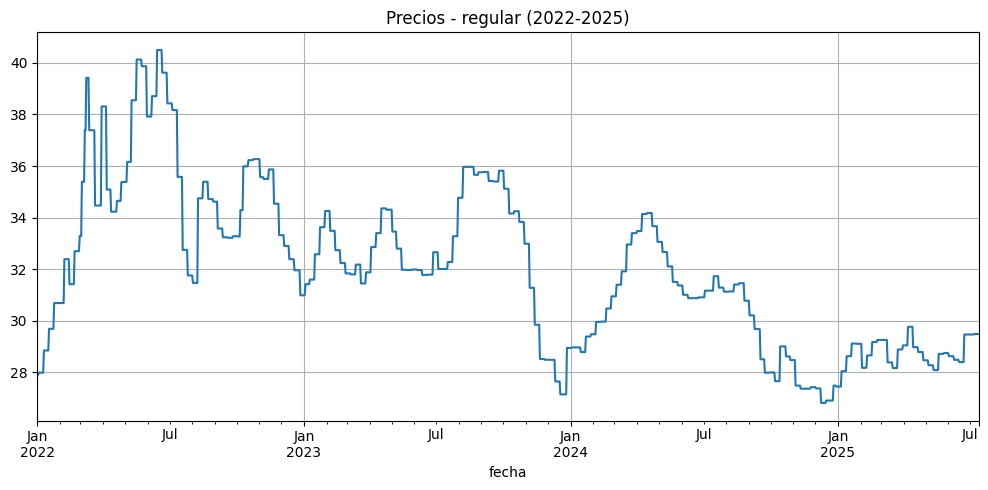

In [23]:
# print(df_precios)
plt.figure(figsize=(10, 5))
df_rango = df_precios["2022":]
df_rango["regular"].plot()
plt.title(f"Precios - regular (2022-2025)")
plt.grid(True)
plt.tight_layout()
plt.show()

Como vimos en el análisis exploratorio y también en la gráfica superior, hubo un claro aumento en el precio de la gasolina a partir del año 2022. Desde entonces ha ido bajando poco a poco en los años posteriores pero nunca ha llegado a bajar a niveles de inicios del año 2021.

Como siguiente paso vamos a descomponer la serie en sus componentes.

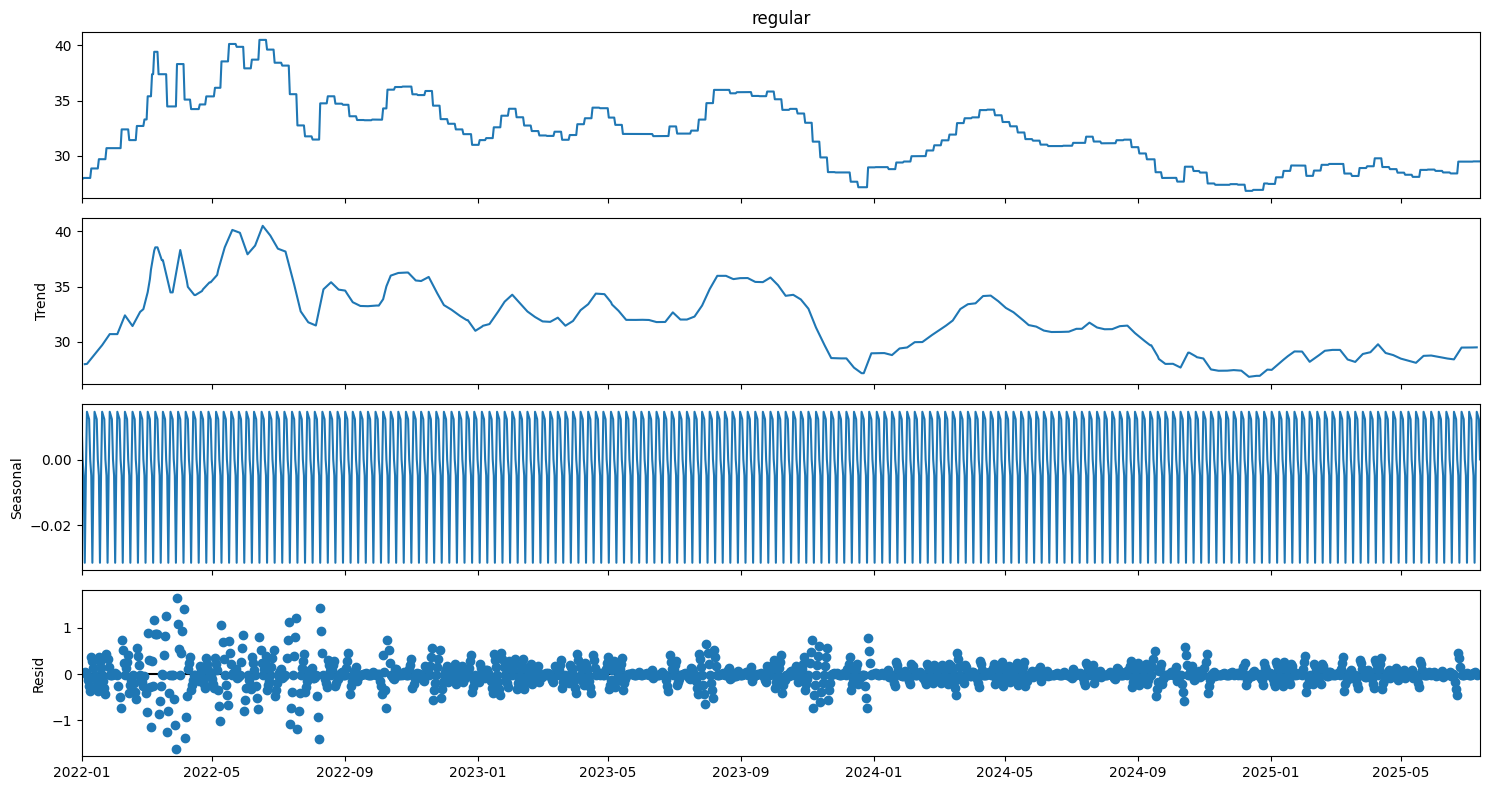

In [24]:
#print(df_precios)
result = seasonal_decompose(df_rango["regular"])
fig = result.plot()
fig.set_size_inches(15, 8)
plt.tight_layout()
plt.show()
# descomposicion.plot()

La serie no es estacional en media ni en varianza, pues como se puede ver por el gráfica, ni la media ni su varianza se mantienen constantes a lo largo del tiempo. Hay que transformarla para acercarnos a una así. Procedemos a realizar el gráfico de autocorrelación:

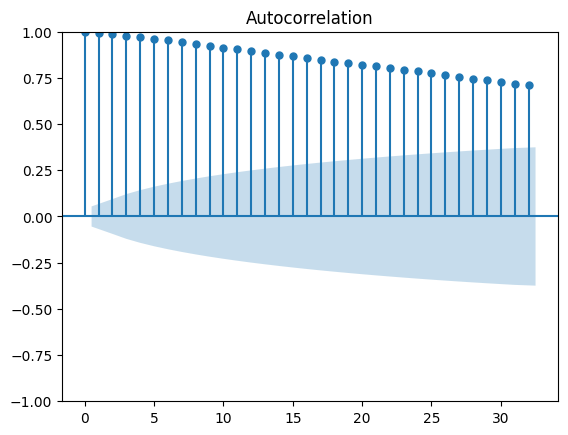

In [25]:
# pd.plotting.lag_plot(df_rango["regular"], lag=1)
fig = plot_acf(df_rango["regular"])
plt.show()

El gráfico de autocorrelación confirma que la variable en sí se encuentra altamente correlacionada consigo misma, es decir, un valor en el pasado nos sirve muchísimo para evaluar un valor en el futuro. Realizando la prueba de Dickey-Fuller:

In [26]:
print('Resultados del Test de Dickey Fuller')
dfTest = adfuller(df_rango["regular"], autolag='AIC')
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller
Estadístico de prueba          -2.558103
p-value                         0.101969
# de retardos usados            9.000000
# de observaciones usadas    1280.000000
Critical Value (1%)            -3.435469
Critical Value (5%)            -2.863801
Critical Value (10%)           -2.567974
dtype: float64


Nos confirma que no es estacionaria en media debido a que el p-value es mayor a 0.05, con lo que no se puede rechazar la hipótesis nula de raíces unitarias. Para volverla estacionaria podemos realizar una diferenciación:

In [27]:
print('Resultados del Test de Dickey Fuller para una diferenciación de la serie')
ts_air_pas_diff = df_rango["regular"].diff()
ts_air_pas_diff.fillna(0,inplace=True)
dfTest = adfuller(ts_air_pas_diff)
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller para una diferenciación de la serie
Estadístico de prueba       -8.521279e+00
p-value                      1.098956e-13
# de retardos usados         1.700000e+01
# de observaciones usadas    1.272000e+03
Critical Value (1%)         -3.435501e+00
Critical Value (5%)         -2.863815e+00
Critical Value (10%)        -2.567981e+00
dtype: float64


Este p-value de 1.09e-13 es mucho menor a 0.05 por lo que podemos rechazar la hipótesis nula de raíces unitarias. Graficando esta serie transformada tenemos:

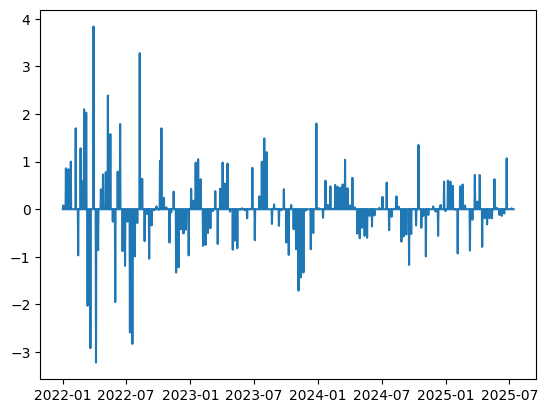

In [28]:
plt.plot(ts_air_pas_diff)

Ahora procedemos a realizar los modelos ARIMA. Debido a que ya nos aseguramos que la serie es estacionaria en media y varianza, podemos asumir un parámetro `d=1`.

Ahora tenemos que determinar los parámetros p,q. Para determinar estos valores podemos realizar unas gráficas de autocorrelación y correlación parcial usando:

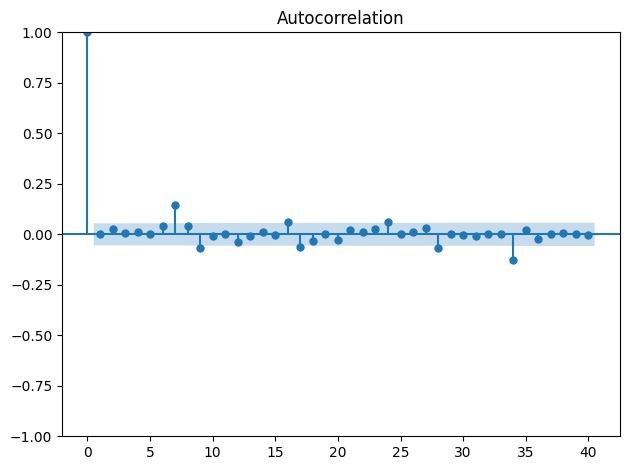

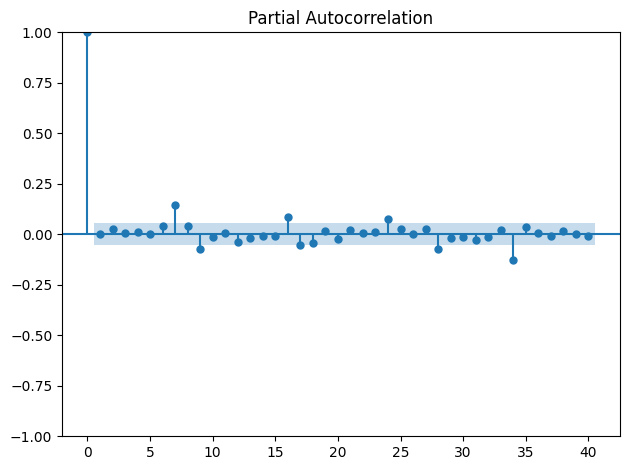

In [29]:
# ACF
fig_acf = plot_acf(ts_air_pas_diff, lags=40)
plt.tight_layout()
plt.show()

# PACF
fig_pacf = plot_pacf(ts_air_pas_diff, lags=40)
plt.tight_layout()
plt.show()

Usando la siguiente "rule of thumb":
* Si el PACF tiene un pico significante en p pero no desués y el ACF decae de forma gradual, esto sugiere un modelo ARIMA(p,d,0).
* Si el ACF tiene un pico significante en q pero no después y el PACF decae de forma gradual, esto sugiere un modelo ARIMA(0,d,q).

En nuestro caso ambos gráficos decaen de forma casi inmediata luego del momento 0. Debido a que ninguna decae realmente, procederemos a utilizar un modelo ARIMA(1,1,1).

El conjunto de entrenamiento será data del 2022-2023. 2024 es nuestro año de validación y dejamos el conjunto del 2025 como el de prueba.

In [30]:
train_data = ts_air_pas_diff["2022":"2023"]
val_data = ts_air_pas_diff["2024":"2024"]
test_data = ts_air_pas_diff["2025":]

mod = ARIMA(train_data, order=(1,1,1))
res = mod.fit()
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                regular   No. Observations:                  730
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -450.294
Date:                Thu, 24 Jul 2025   AIC                            906.587
Time:                        16:17:09   BIC                            920.362
Sample:                    01-01-2022   HQIC                           911.902
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0005      0.156     -0.003      0.997      -0.306       0.305
ma.L1         -0.9960      0.007   -134.588      0.000      -1.011      -0.982
sigma2         0.2001      0.003     63.320      0.0

d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Si el modelo es uno bueno entonces podríamos simplemente graficar sus residuos y deberían de verse como _white noise_. 

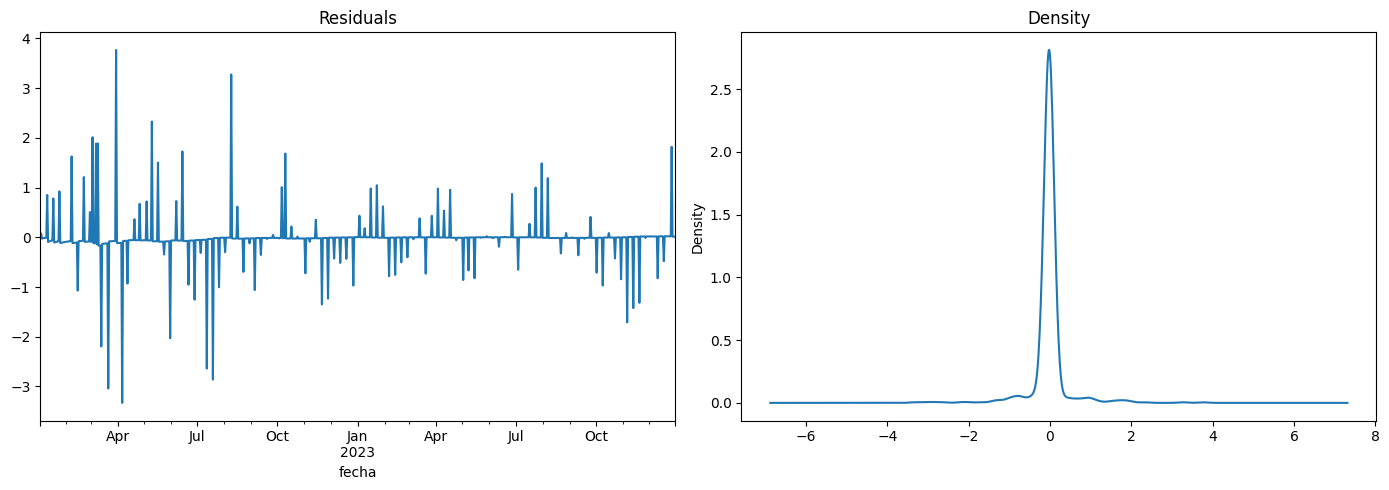

In [31]:
residuals = res.resid[1:]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(title="Density", kind="kde", ax=ax[1])

plt.tight_layout()
plt.show()


Éxito! Podemos ver que los residuos aparentan ser random y que la densidad de los residuos parecen una campana de gauss estrecha.

Por último se decidió probar con otros modelos, como: 
* ARIMA(1,1,0)
* ARIMA(0,1,1)

Modelo ARIMA(1,1,0)
                               SARIMAX Results                                
Dep. Variable:                regular   No. Observations:                  730
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -588.116
Date:                Thu, 24 Jul 2025   AIC                           1180.232
Time:                        16:17:09   BIC                           1189.416
Sample:                    01-01-2022   HQIC                          1183.775
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5132      0.014    -35.718      0.000      -0.541      -0.485
sigma2         0.2938      0.006     49.930      0.000       0.282       0.305
Ljung-Box (L1) (Q):             

d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


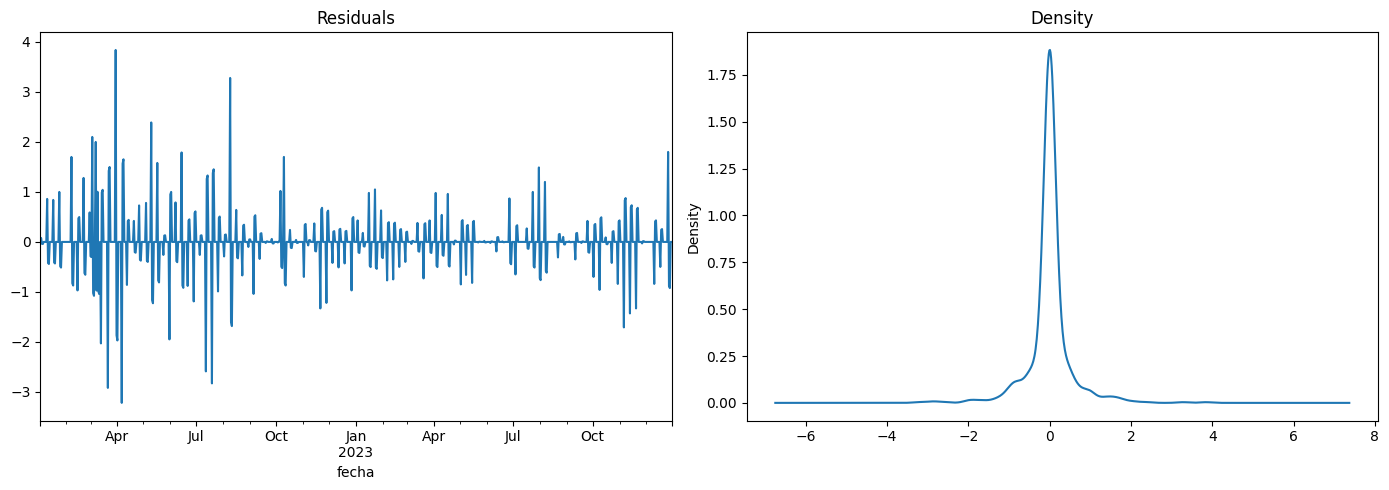

In [32]:
print("Modelo ARIMA(1,1,0)")
mod = ARIMA(train_data, order=(1,1,0))
res = mod.fit()
print(res.summary())

residuals = res.resid[1:]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(title="Density", kind="kde", ax=ax[1])

plt.tight_layout()
plt.show()


Modelo ARIMA(0,1,1)
                               SARIMAX Results                                
Dep. Variable:                regular   No. Observations:                  730
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -450.294
Date:                Thu, 24 Jul 2025   AIC                            904.588
Time:                        16:17:09   BIC                            913.771
Sample:                    01-01-2022   HQIC                           908.131
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9961      0.007   -134.748      0.000      -1.011      -0.982
sigma2         0.2001      0.003     63.691      0.000       0.194       0.206
Ljung-Box (L1) (Q):             

d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


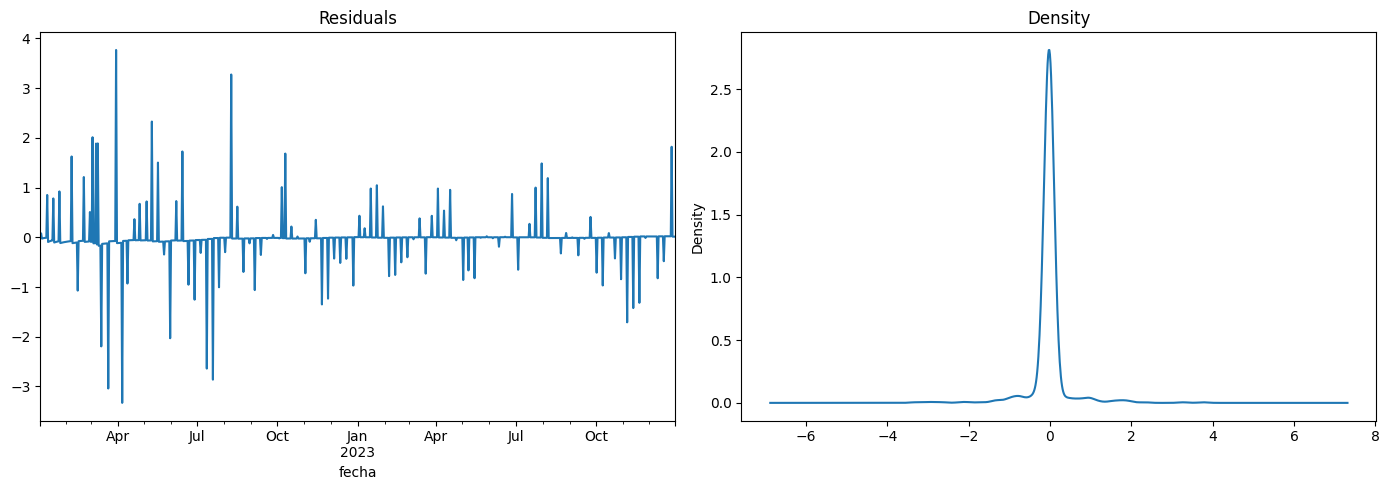

In [33]:
print("Modelo ARIMA(0,1,1)")
mod = ARIMA(train_data, order=(0,1,1))
res = mod.fit()
print(res.summary())

residuals = res.resid[1:]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(title="Density", kind="kde", ax=ax[1])

plt.tight_layout()
plt.show()

Modelo ARIMA(0,1,1)
                               SARIMAX Results                                
Dep. Variable:                regular   No. Observations:                  730
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -450.294
Date:                Thu, 24 Jul 2025   AIC                            904.588
Time:                        16:17:09   BIC                            913.771
Sample:                    01-01-2022   HQIC                           908.131
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9961      0.007   -134.748      0.000      -1.011      -0.982
sigma2         0.2001      0.003     63.691      0.000       0.194       0.206
Ljung-Box (L1) (Q):             

d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


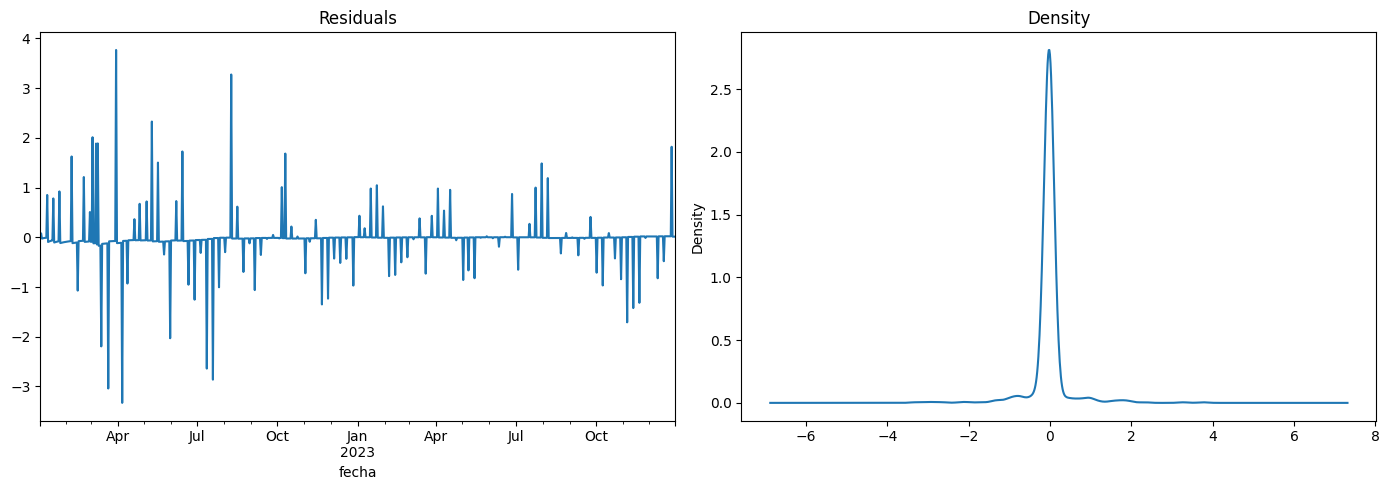

In [34]:
print("Modelo ARIMA(0,1,1)")
mod = ARIMA(train_data, order=(0,1,1))
res = mod.fit()
print(res.summary())

residuals = res.resid[1:]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))  

residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(title="Density", kind="kde", ax=ax[1])
plt.tight_layout()
plt.show()


Ahora vamos a ver cómo se comparan con el dataset de validación:

d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: Val

<Axes: xlabel='fecha'>

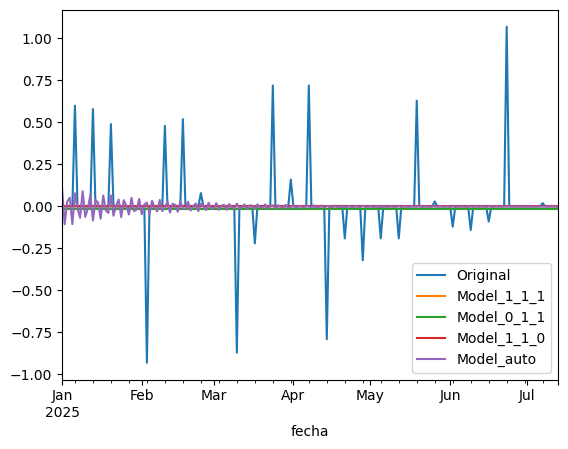

In [35]:
mods = [ 
    ARIMA(train_data, order=(1,1,1)),
    ARIMA(train_data, order=(0,1,1)),
    ARIMA(train_data, order=(1,1,0))
]
fitted = [x.fit() for x in mods]

auto_model = pm.auto_arima(train_data, seasonal=False)
forecast = auto_model.predict(len(test_data))

newDF = pd.DataFrame({
    'Original': test_data
})

newDF = newDF.assign(
    Model_1_1_1 = lambda _: list(fitted[0].forecast(len(test_data))),
    Model_0_1_1 = lambda _: list(fitted[1].forecast(len(test_data))),
    Model_1_1_0 = lambda _: list(fitted[2].forecast(len(test_data))),
    Model_auto = lambda _ : list(forecast)
)

newDF.plot()

Como se puede ver las gráficas son bien parecidas entre sí, ningún modelo predice de buena manera los datos.

#### Otros modelos
Los siguientes que vamos a probar son los modelos Prophet, holt-winters y redes neuronales.

Modelo prophet ==================================================
            ds     y
0   2022-01-01  0.00
1   2022-01-02  0.00
2   2022-01-03  0.08
3   2022-01-04  0.00
4   2022-01-05  0.00
..         ...   ...
725 2023-12-27  1.80
726 2023-12-28  0.00
727 2023-12-29  0.00
728 2023-12-30  0.00
729 2023-12-31  0.00

[730 rows x 2 columns]


16:17:13 - cmdstanpy - INFO - Chain [1] start processing
16:17:15 - cmdstanpy - INFO - Chain [1] done processing
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\prophet\plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\prophet\plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\prophet\plot.py:228: FutureWarning: The behavior of DatetimeProperties

Modelo Holt-Winters ==================================================


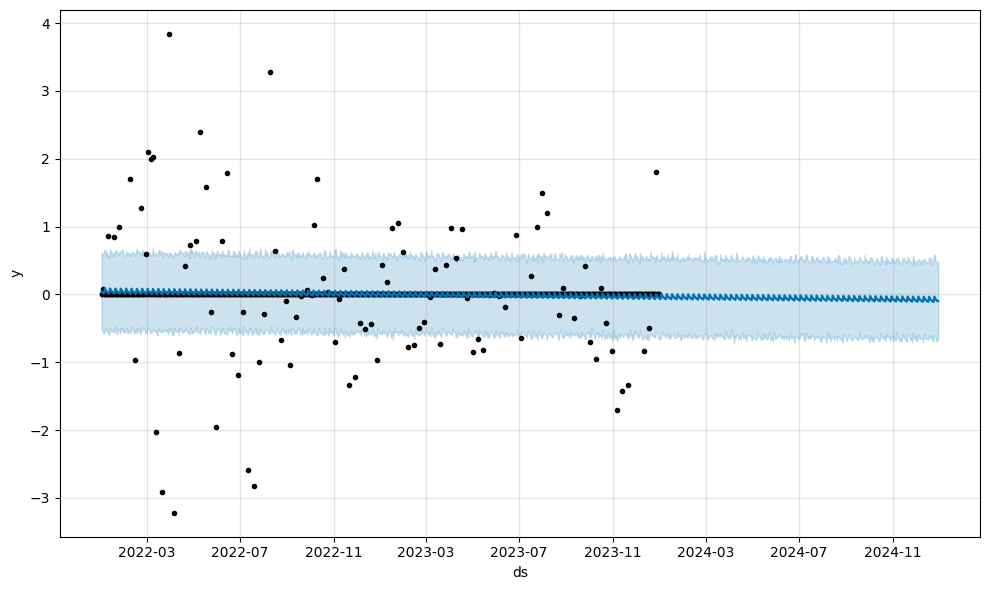

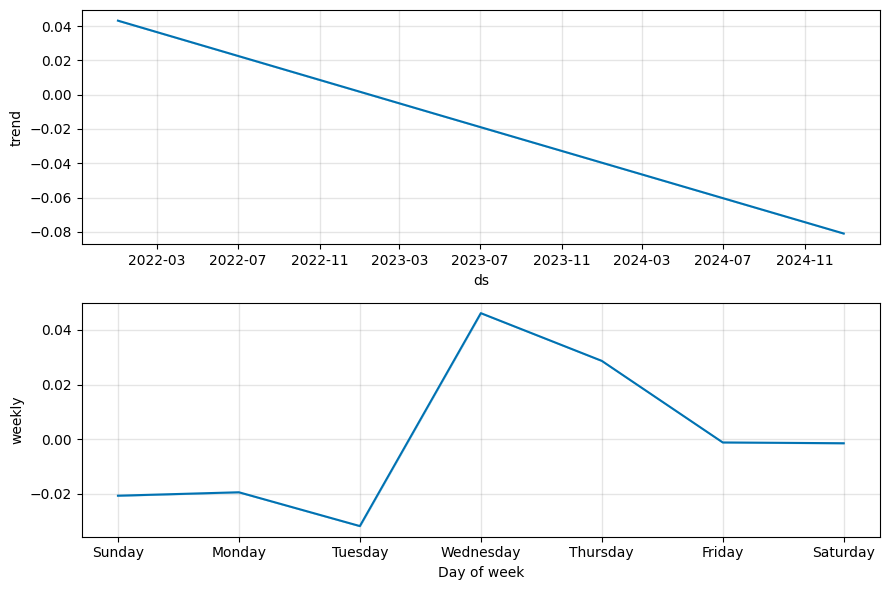

In [36]:
print("Modelo prophet ==================================================")
from prophet import Prophet

df_train = pd.DataFrame({
    "ds": train_data.index,
    "y": list(train_data)
})

print(df_train)

m = Prophet()
m.fit(df_train)

future = m.make_future_dataframe(periods=365)
future.tail()
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()
fig1 = m.plot(forecast)
fig2 = m.plot_components(forecast)

print("Modelo Holt-Winters ==================================================")
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model = ExponentialSmoothing(train_data, trend='add', seasonal='add', seasonal_periods=12)
fit = model.fit()

forecast_steps = 6  # Number of steps to forecast
predictions = fit.forecast(forecast_steps)

Modelo de Redes Neuronales ==================================================
RMSE en prueba: 0.1820
MAE en prueba: 0.0649


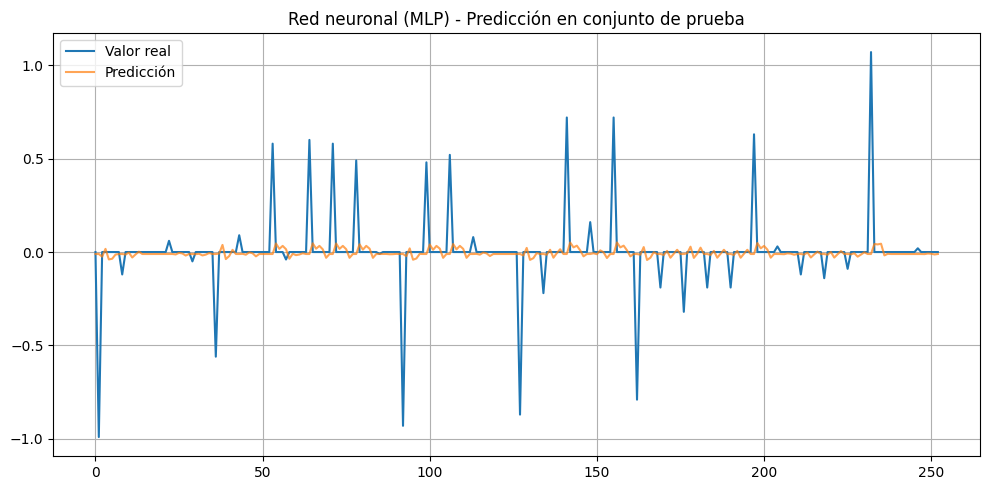

In [37]:
print("Modelo de Redes Neuronales ==================================================")
# === Escalado y preparación de datos ===
scaler = StandardScaler()
ts_air_pas_diff.fillna(0, inplace=True)

# Convertir a DataFrame con columnas año, mes, día, valor
ts_air_pass_diff_df = pd.DataFrame({
    "year": ts_air_pas_diff.index.year,
    "month": ts_air_pas_diff.index.month,
    "day": ts_air_pas_diff.index.day,
    "price": list(ts_air_pas_diff)
})
ts_air_pass_diff_df.set_index(["year", "month", "day"], inplace=True)

# Escalar la serie
air_pass_scaled = scaler.fit_transform(ts_air_pass_diff_df[["price"]])

# === División en conjuntos: entrenamiento, validación, prueba ===
entrenamiento = round(0.6 * len(air_pass_scaled))
val_prueba = round(0.2 * len(air_pass_scaled))

train = air_pass_scaled[:entrenamiento]
validation = air_pass_scaled[entrenamiento:entrenamiento + val_prueba]
test = air_pass_scaled[entrenamiento + val_prueba:]

# === Función para convertir a formato supervisado ===
def supervisada(serie, retrasos=1):
    serie_x, serie_y = [], []
    for i in range(len(serie) - retrasos):
        serie_x.append(serie[i:i + retrasos, 0])
        serie_y.append(serie[i + retrasos, 0])
    return np.array(serie_x), np.array(serie_y)

# === Generación de conjuntos supervisados ===
retrasos = 5  # Puedes ajustar este valor
x_train, y_train = supervisada(train, retrasos)
x_val, y_val = supervisada(validation, retrasos)
x_test, y_test = supervisada(test, retrasos)

# === Entrenamiento del modelo ===
modelo = MLPRegressor(hidden_layer_sizes=(100,50), activation='relu', max_iter=1000, early_stopping=True, random_state=1)
# modelo = MLPRegressor(hidden_layer_sizes=(50,), activation='relu', max_iter=500, random_state=1)
modelo.fit(x_train, y_train)

# === Predicciones ===
pred_val = modelo.predict(x_val)
pred_test = modelo.predict(x_test)

# === Inversión de la escala para interpretar los valores ===
pred_test_inv = scaler.inverse_transform(np.array(pred_test).reshape(-1,1))
y_test_inv = scaler.inverse_transform(np.array(y_test).reshape(-1,1))

# === Métricas de evaluación ===
rmse = np.sqrt(mean_squared_error(y_test_inv, pred_test_inv))
mae = mean_absolute_error(y_test_inv, pred_test_inv)

print(f"RMSE en prueba: {rmse:.4f}")
print(f"MAE en prueba: {mae:.4f}")

# === Gráfico de resultados ===
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Valor real')
plt.plot(pred_test_inv, label='Predicción', alpha=0.7)
plt.title("Red neuronal (MLP) - Predicción en conjunto de prueba")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Predicción

In [38]:
resultados_modelos = [
    ["ARIMA(0,1,1)", mean_squared_error(test_data, newDF["Model_0_1_1"], squared=False),
     mean_absolute_error(test_data, newDF["Model_0_1_1"])],
    ["ARIMA(1,1,1)", mean_squared_error(test_data, newDF["Model_1_1_1"], squared=False),
     mean_absolute_error(test_data, newDF["Model_1_1_1"])],
    ["ARIMA(1,1,0)", mean_squared_error(test_data, newDF["Model_1_1_0"], squared=False),
     mean_absolute_error(test_data, newDF["Model_1_1_0"])],
    ["ARIMA auto", mean_squared_error(test_data, newDF["Model_auto"], squared=False),
     mean_absolute_error(test_data, newDF["Model_auto"])],
    ["MLP", rmse, mae]  # ya calculados anteriormente
]

# Mostrar tabla
print(tabulate(resultados_modelos, headers=["Modelo", "RMSE", "MAE"], floatfmt=".4f"))

Modelo          RMSE     MAE
------------  ------  ------
ARIMA(0,1,1)  0.1856  0.0637
ARIMA(1,1,1)  0.1856  0.0637
ARIMA(1,1,0)  0.1844  0.0524
ARIMA auto    0.1864  0.0643
MLP           0.1820  0.0649


### Consumo de diésel

Para comenzar a analizar la serie del consumo de diesel primero graficamos la serie:

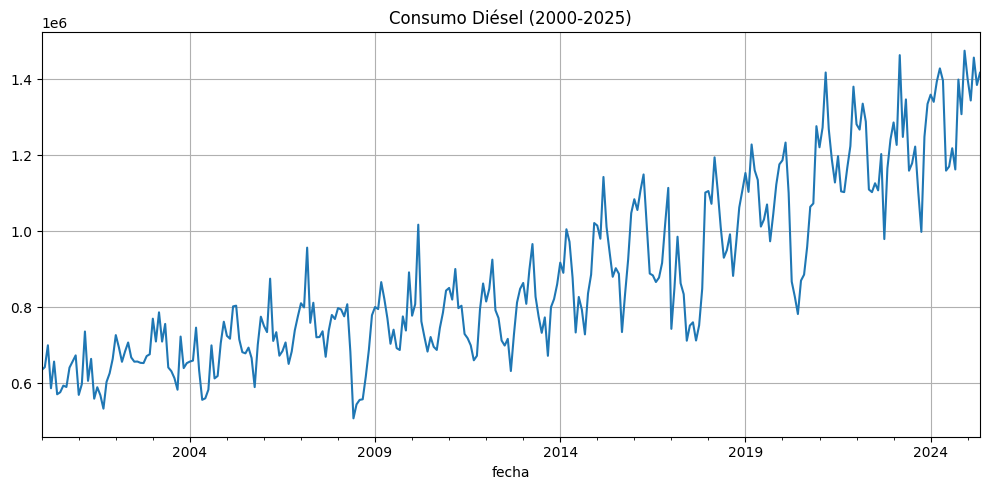

In [39]:
plt.figure(figsize=(10, 5))
df_rango = df_consumo
df_rango["diesel"].plot()
plt.title(f"Consumo Diésel (2000-2025)")
plt.grid(True)
plt.tight_layout()
plt.show()

Como vimos en el análisis exploratorio muestra una clara tendencia al alza, si la descomponemos en componentes tenemos:

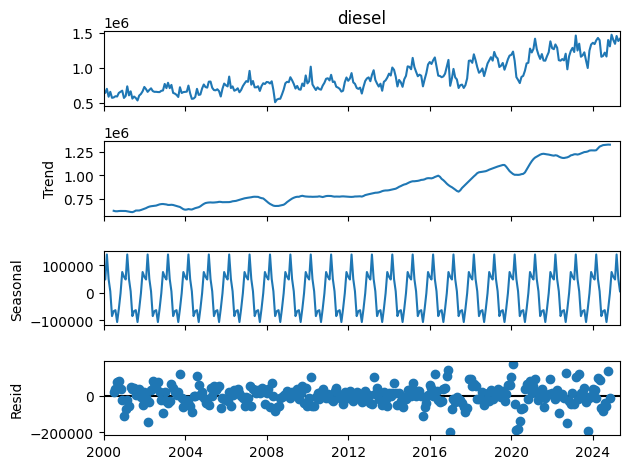

In [40]:
result = seasonal_decompose(df_rango["diesel"])
fig = result.plot()
plt.show()

Como se puede ver la tendencia es al alza y además presenta un comportamiento de temporadas, siendo la gráfica casi exacta en ese sentido. Procedemos a realizar el gráfico de autocorrelación.

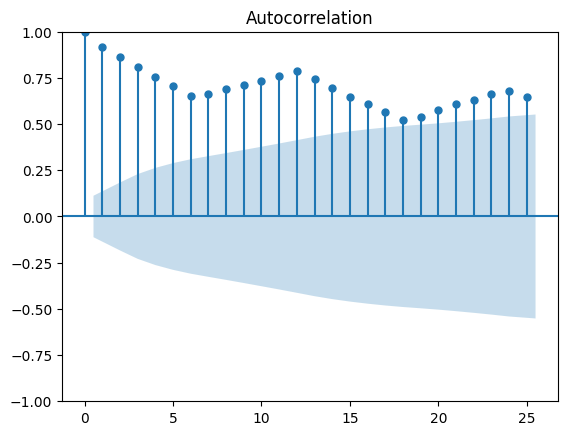

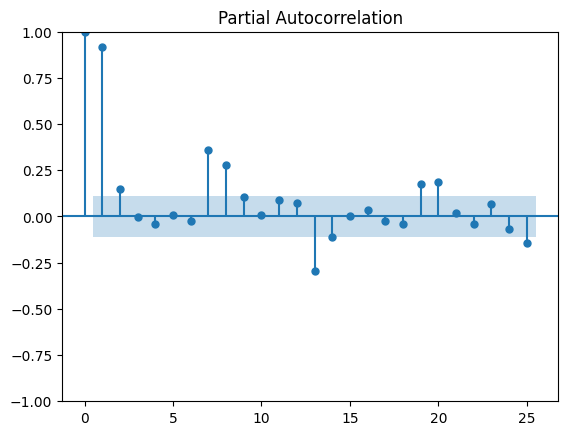

In [41]:
fig_acf = plot_acf(df_rango["diesel"])
plt.show()

fig_pacf = plot_pacf(df_rango["diesel"])
plt.show()

Como se puede ver por los gráficos de autocorrelación, los datos tienen una alta correlación entre sí, aunque parcialmente casi no se encuentren correlacionados en su conjunto total sí lo son. Tiene sentido debido a su marcada temporadas. Realizando la prueba de Dickey-Fuller:

In [42]:
print('Resultados del Test de Dickey Fuller')
dfTest = adfuller(df_rango["regular"], autolag='AIC')
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller
Estadístico de prueba          2.292167
p-value                        0.998950
# de retardos usados          14.000000
# de observaciones usadas    290.000000
Critical Value (1%)           -3.453102
Critical Value (5%)           -2.871559
Critical Value (10%)          -2.572108
dtype: float64


Podemos ver que el p-value es uno mucho más grande que 0.05, al aplicarle una diferenciación lo logramos reducir un poco:

In [43]:
print('Resultados del Test de Dickey Fuller para una diferenciación de la serie')
ts_air_pas_diff = df_rango["regular"].diff()
ts_air_pas_diff.fillna(0,inplace=True)
dfTest = adfuller(ts_air_pas_diff)
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller para una diferenciación de la serie
Estadístico de prueba         -4.382493
p-value                        0.000319
# de retardos usados          16.000000
# de observaciones usadas    288.000000
Critical Value (1%)           -3.453262
Critical Value (5%)           -2.871628
Critical Value (10%)          -2.572146
dtype: float64


Esta serie ya tiene un p-value menor a 0.05 por lo que podemos rechazar la hipótesis nula y nos queda una serie con media estacionaria. Se ve de la siguiente forma:

<Axes: xlabel='fecha'>

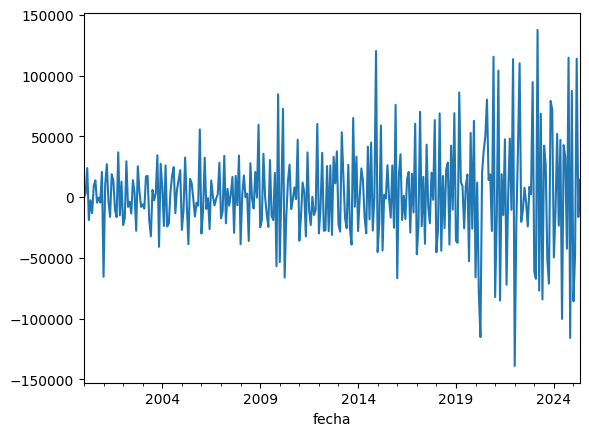

In [44]:
ts_air_pas_diff.plot()

Siguiendo la rule of thumb mencionada anteriormente esta serie tiene una autorocorrelación que disminuye gradualmente mientras que tiene una correlación parcial con pocos picos. Podemos usar el modelo ARIMA(0,1,1).

Antes de usar los modelos tenemos que dividir la data en entrenamiento y validación, para entrenamiento vamos a utilizar el año 2023 debido a las marcadas temporadas de la data demostrada cuando la dividimos en frecuencias, tenemos de validación al año 2024 y de test al año 2025.

In [45]:
print("División del dataset:")

print("Entrenamiento")
train_data = ts_air_pas_diff[:"2023"]
print(train_data)

print("Validación")
val_data = ts_air_pas_diff["2024":"2024"]
print(val_data)

print("Testing")
test_data = ts_air_pas_diff["2025":]
print(test_data)

División del dataset:
Entrenamiento
fecha
2000-01-01        0.00
2000-02-01     2885.76
2000-03-01    23968.60
2000-04-01   -18819.16
2000-05-01    -2516.06
                ...   
2023-08-01    26534.97
2023-09-01   -51901.29
2023-10-01   -71111.57
2023-11-01    79206.82
2023-12-01    72285.14
Name: regular, Length: 288, dtype: float64
Validación
fecha
2024-01-01    -49524.99
2024-02-01    -11967.97
2024-03-01     52031.54
2024-04-01    -23418.55
2024-05-01     47179.99
2024-06-01   -100124.83
2024-07-01     42856.32
2024-08-01     32733.37
2024-09-01    -42369.00
2024-10-01    114765.34
2024-11-01   -115880.69
2024-12-01     87427.13
Name: regular, dtype: float64
Testing
fecha
2025-01-01    -85671.14
2025-02-01    -47155.72
2025-03-01    113954.54
2025-04-01    -16326.72
2025-05-01     14416.66
Name: regular, dtype: float64


#### Modelos ARIMA

Entrenando los modelos tenemos:

d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473:

<Axes: xlabel='fecha'>

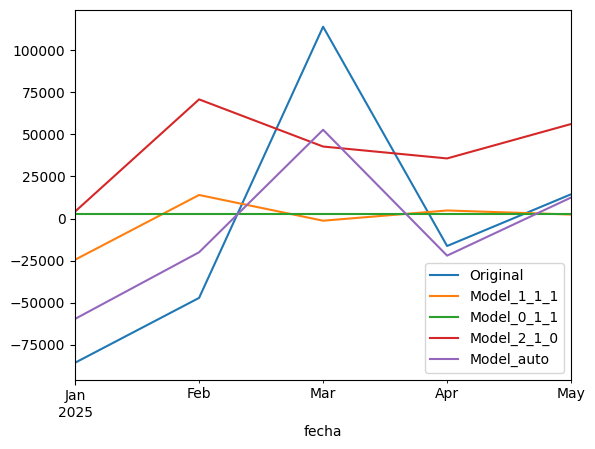

In [46]:
mods = [ 
    ARIMA(train_data, order=(1,1,1)),
    ARIMA(train_data, order=(0,1,1)),
    ARIMA(train_data, order=(2,1,0))
]
fitted = [x.fit() for x in mods]

auto_model = pm.auto_arima(train_data, seasonal=True, m=12)
forecast = auto_model.predict(len(test_data))

newDF = pd.DataFrame({
    'Original': test_data
})

newDF = newDF.assign(
    Model_1_1_1 = lambda _: list(fitted[0].forecast(len(test_data))),
    Model_0_1_1 = lambda _: list(fitted[1].forecast(len(test_data))),
    Model_2_1_0 = lambda _: list(fitted[2].forecast(len(test_data))),
    Model_auto = lambda _: list(forecast)
)

newDF.plot()

El mejor de los modelos de ARIMA generados fue el automático dado por auto_arima como se puede ver por la gráfica superior. Ya que es el que más se ajusta a los datos.

#### Otros Modelos

Procediendo a utilizar los demás modelos solicitados como Prophet y holt-winters tenemos:

16:17:49 - cmdstanpy - INFO - Chain [1] start processing
16:17:49 - cmdstanpy - INFO - Chain [1] done processing


Modelo prophet ==================================================
            ds         y
0   2000-01-01      0.00
1   2000-02-01   2885.76
2   2000-03-01  23968.60
3   2000-04-01 -18819.16
4   2000-05-01  -2516.06
..         ...       ...
283 2023-08-01  26534.97
284 2023-09-01 -51901.29
285 2023-10-01 -71111.57
286 2023-11-01  79206.82
287 2023-12-01  72285.14

[288 rows x 2 columns]


d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\prophet\plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\prophet\plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\prophet\plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects in

Modelo Holt-Winters ==================================================


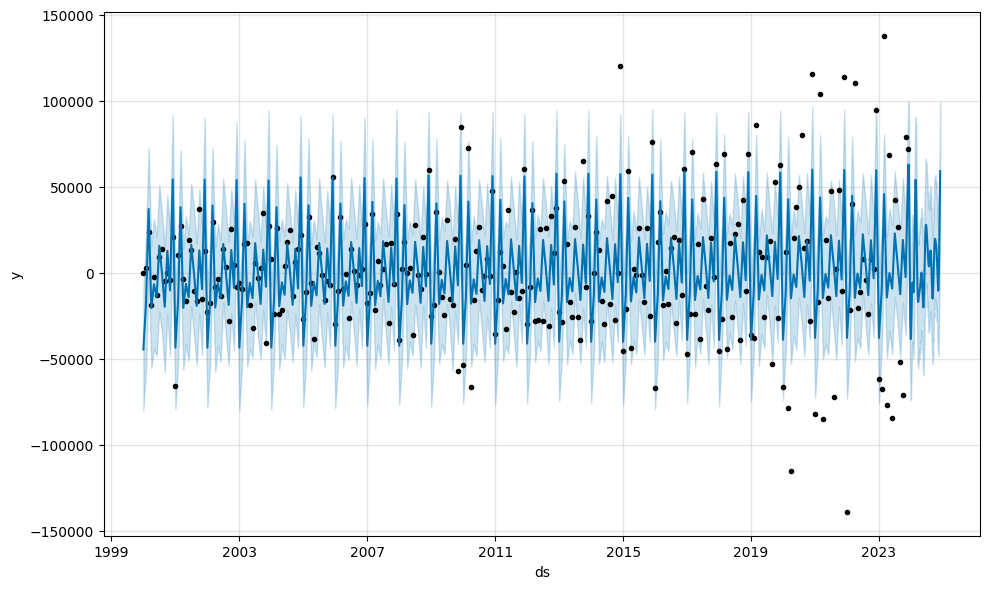

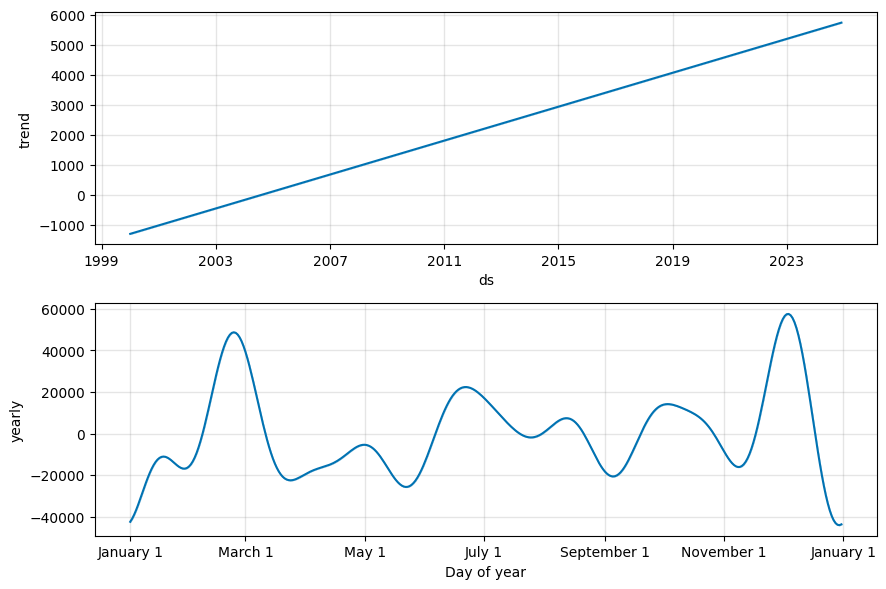

In [47]:
print("Modelo prophet ==================================================")
from prophet import Prophet

df_train = pd.DataFrame({
    "ds": train_data.index,
    "y": list(train_data)
})

print(df_train)

m = Prophet()
m.fit(df_train)

future = m.make_future_dataframe(periods=365)
future.tail()
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()
fig1 = m.plot(forecast)
fig2 = m.plot_components(forecast)

print("Modelo Holt-Winters ==================================================")
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model = ExponentialSmoothing(train_data, trend='add', seasonal='add', seasonal_periods=12)
fit = model.fit()

forecast_steps = 6  # Number of steps to forecast
predictions = fit.forecast(forecast_steps)

Modelo de Redes Neuronales ==================================================
RMSE en prueba: 65071.5948
MAE en prueba: 54497.8127


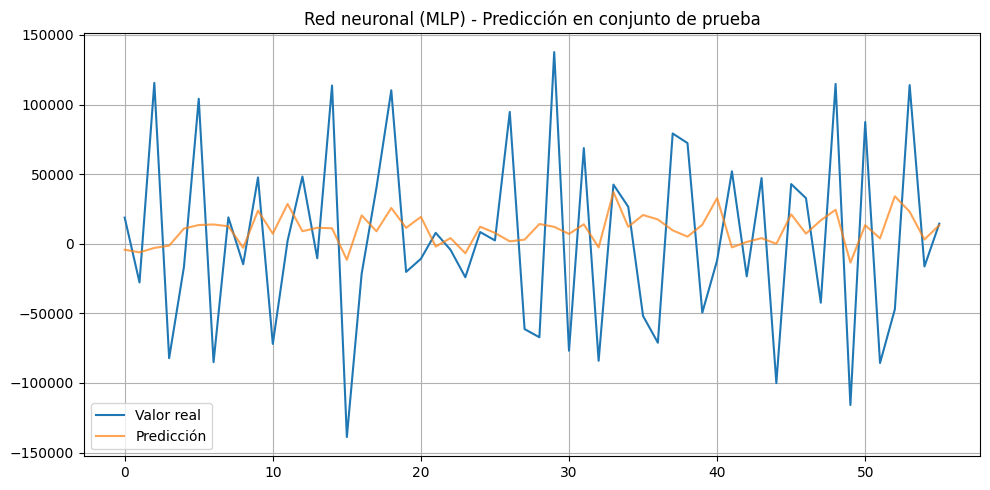

In [48]:
print("Modelo de Redes Neuronales ==================================================")

# === Escalado y preparación de datos ===
scaler = StandardScaler()
ts_air_pas_diff.fillna(0, inplace=True)

# Convertir a DataFrame con columnas año, mes, día, valor
ts_air_pass_diff_df = pd.DataFrame({
    "year": ts_air_pas_diff.index.year,
    "month": ts_air_pas_diff.index.month,
    "day": ts_air_pas_diff.index.day,
    "value": list(ts_air_pas_diff)
})
ts_air_pass_diff_df.set_index(["year", "month", "day"], inplace=True)

# Escalar la serie
diesel_scaled = scaler.fit_transform(ts_air_pass_diff_df[["value"]])

# === División de datos ===
entrenamiento = round(0.6 * len(diesel_scaled))
val_prueba = round(0.2 * len(diesel_scaled))

train = diesel_scaled[:entrenamiento]
validation = diesel_scaled[entrenamiento:entrenamiento + val_prueba]
test = diesel_scaled[entrenamiento + val_prueba:]

# === Transformación supervisada ===
def supervisada(serie, retrasos=5):
    serie_x, serie_y = [], []
    for i in range(len(serie) - retrasos):
        serie_x.append(serie[i:i + retrasos, 0])
        serie_y.append(serie[i + retrasos, 0])
    return np.array(serie_x), np.array(serie_y)

x_train, y_train = supervisada(train)
x_val, y_val = supervisada(validation)
x_test, y_test = supervisada(test)

# === Entrenamiento del modelo ===
modelo = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', max_iter=1000, early_stopping=True, random_state=1)
modelo.fit(x_train, y_train)

# === Predicción ===
pred_test = modelo.predict(x_test)

# === Inversión de la escala ===
pred_test_inv = scaler.inverse_transform(pred_test.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# === Métricas ===
rmse = np.sqrt(mean_squared_error(y_test_inv, pred_test_inv))
mae = mean_absolute_error(y_test_inv, pred_test_inv)

print(f"RMSE en prueba: {rmse:.4f}")
print(f"MAE en prueba: {mae:.4f}")

# === Gráfico ===
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Valor real')
plt.plot(pred_test_inv, label='Predicción', alpha=0.7)
plt.title("Red neuronal (MLP) - Predicción en conjunto de prueba")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Predicción

In [49]:
# Comparación de métricas
resultados_modelos = [
    ["ARIMA(0,1,1)", mean_squared_error(newDF["Original"], newDF["Model_0_1_1"], squared=False),
     mean_absolute_error(newDF["Original"], newDF["Model_0_1_1"])],
    ["ARIMA(1,1,1)", mean_squared_error(newDF["Original"], newDF["Model_1_1_1"], squared=False),
     mean_absolute_error(newDF["Original"], newDF["Model_1_1_1"])],
    ["ARIMA(2,1,0)", mean_squared_error(newDF["Original"], newDF["Model_2_1_0"], squared=False),
     mean_absolute_error(newDF["Original"], newDF["Model_2_1_0"])],
    ["ARIMA auto", mean_squared_error(newDF["Original"], newDF["Model_auto"], squared=False),
     mean_absolute_error(newDF["Original"], newDF["Model_auto"])],
    ["MLP", rmse, mae]
]

# Convertir a DataFrame
resultados_df = pd.DataFrame(resultados_modelos, columns=["Modelo", "RMSE", "MAE"])
print(resultados_df)

         Modelo          RMSE           MAE
0  ARIMA(0,1,1)  68068.327921  56029.013383
1  ARIMA(1,1,1)  65357.342183  54151.470145
2  ARIMA(2,1,0)  79363.421225  74541.039838
3    ARIMA auto  32246.902730  24407.496708
4           MLP  65071.594815  54497.812690


### Importaciones de glp

Comenzando igual que los anteriores, graficamos la serie:

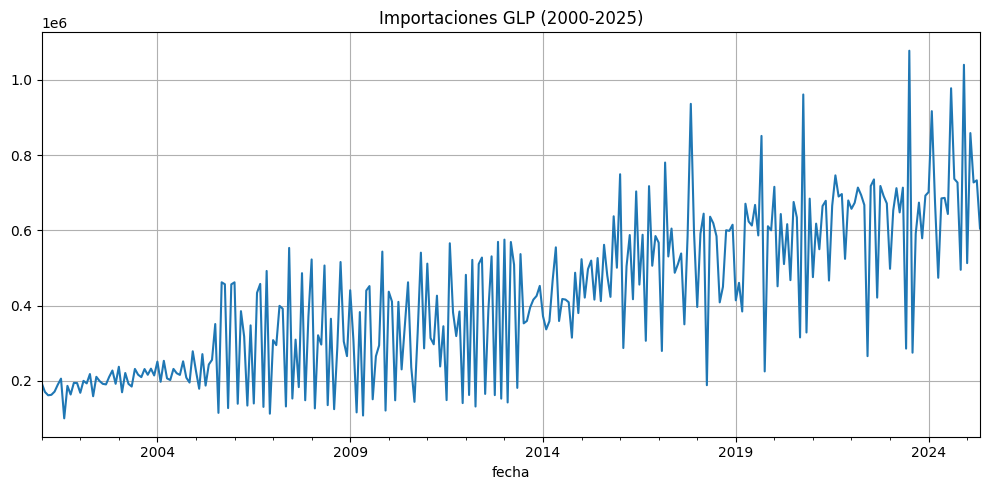

In [50]:
plt.figure(figsize=(10, 5))
df_rango = df_consumo
df_importaciones["glp"].plot()
plt.title(f"Importaciones GLP (2000-2025)")
plt.grid(True)
plt.tight_layout()
plt.show()

Como vimos en el análisis exploratorio es un dataset muy variable, pero muestra una tendencia al alza, si la descomponemos tenemos:

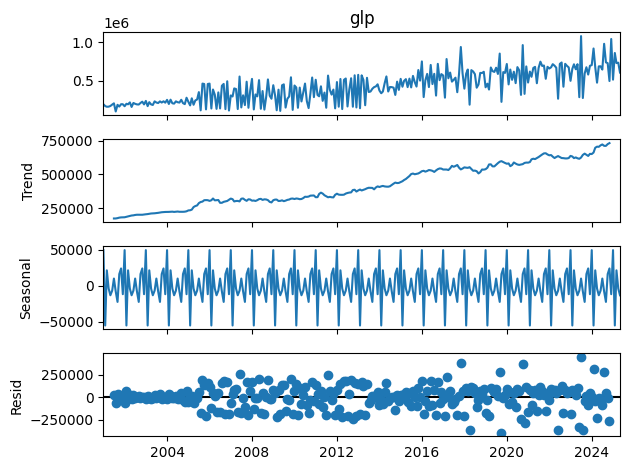

In [51]:
result = seasonal_decompose(df_importaciones["glp"])
fig = result.plot()
plt.show()

Podemos ver que tiene unas temporadas marcadas y una tendencia al alza. El siguiente paso es ver su autocorrelación:

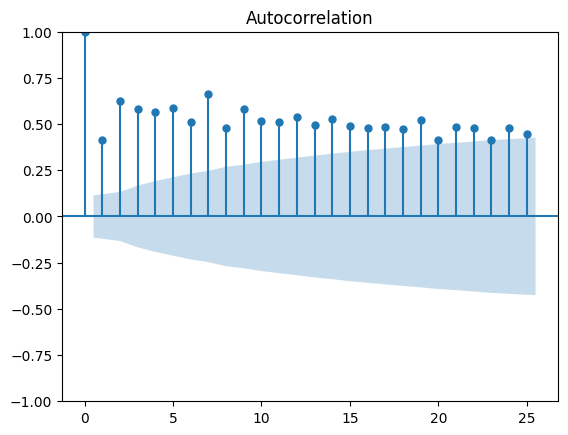

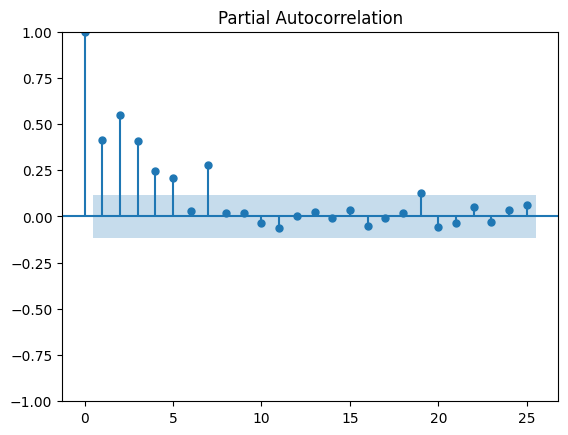

In [52]:
fig_acf = plot_acf(df_importaciones["glp"])
plt.show()

fig_pacf = plot_pacf(df_importaciones["glp"])
plt.show()

Tiene una autocorrelación alta pero debido a sus temporadas la correlación parcial decae rápidamente. Haciendo el test de Dickey Fuller tenemos:

In [53]:
print('Resultados del Test de Dickey Fuller')
dfTest = adfuller(df_importaciones["glp"], autolag='AIC')
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller
Estadístico de prueba         -0.281940
p-value                        0.928023
# de retardos usados           9.000000
# de observaciones usadas    283.000000
Critical Value (1%)           -3.453670
Critical Value (5%)           -2.871808
Critical Value (10%)          -2.572241
dtype: float64


Lo cual es mayor a 0.05, procedemos a aplicar las diferencias y tenemos:

In [54]:
print('Resultados del Test de Dickey Fuller para una diferenciación de la serie')
ts_air_pas_diff = np.log(df_importaciones["glp"]).diff()
ts_air_pas_diff.fillna(0,inplace=True)
dfTest = adfuller(ts_air_pas_diff)
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller para una diferenciación de la serie
Estadístico de prueba       -1.149170e+01
p-value                      4.719084e-21
# de retardos usados         8.000000e+00
# de observaciones usadas    2.840000e+02
Critical Value (1%)         -3.453587e+00
Critical Value (5%)         -2.871771e+00
Critical Value (10%)        -2.572222e+00
dtype: float64


Lo cual es un p-value mucho menor a 0.05. Graficando el resultado tenemos:

<Axes: xlabel='fecha'>

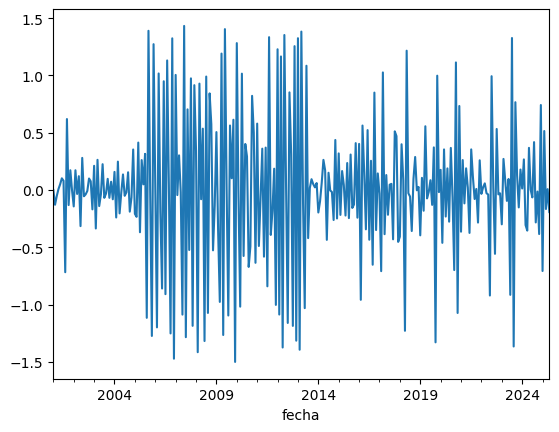

In [55]:
ts_air_pas_diff.plot()

Con esta diferenciación y logaritmo que aplicamos la variación se redujo drásticamente en varianza y la variación de media fue casi eliminada. Podemos proceder con la siguiente fase, dividir el dataset y crear los modelos ARIMA. Debido a las temporadas detectadas en el dataset, podemos simplemente usar la data del año 2023 como entrenamiento, 2024 como validación y 2025 como testeo. Teniendo entonces:

In [56]:
print("División del dataset:")

print("Entrenamiento")
train_data = ts_air_pas_diff[:"2023"]
print(train_data)

print("Validación")
val_data = ts_air_pas_diff["2024":"2024"]
print(val_data)

print("Testing")
test_data = ts_air_pas_diff["2025":]
print(test_data)

División del dataset:
Entrenamiento
fecha
2001-01-01    0.000000
2001-02-01   -0.128270
2001-03-01   -0.053335
2001-04-01    0.007457
2001-05-01    0.050645
                ...   
2023-08-01   -1.365373
2023-09-01    0.766345
2023-10-01    0.129589
2023-11-01   -0.151656
2023-12-01    0.178896
Name: glp, Length: 276, dtype: float64
Validación
fecha
2024-01-01    0.013473
2024-02-01    0.267286
2024-03-01   -0.305662
2024-04-01   -0.353864
2024-05-01    0.368139
2024-06-01    0.001865
2024-07-01   -0.064287
2024-08-01    0.418103
2024-09-01   -0.282680
2024-10-01   -0.013437
2024-11-01   -0.384005
2024-12-01    0.741913
Name: glp, dtype: float64
Testing
fecha
2025-01-01   -0.706614
2025-02-01    0.514918
2025-03-01   -0.165821
2025-04-01    0.007706
2025-05-01   -0.192111
Name: glp, dtype: float64


#### Modelos ARIMA

Generando los modelos ARIMA tenemos:

d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473:

<Axes: xlabel='fecha'>

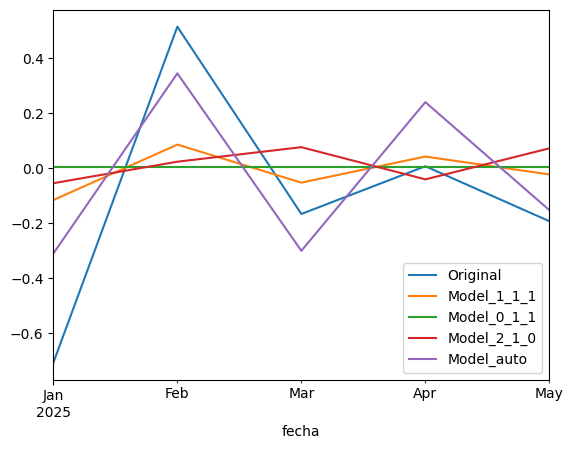

In [57]:
mods = [ 
    ARIMA(train_data, order=(1,1,1)),
    ARIMA(train_data, order=(0,1,1)),
    ARIMA(train_data, order=(2,1,0))
]
fitted = [x.fit() for x in mods]

auto_model = pm.auto_arima(train_data, seasonal=True, m=12)
forecast = auto_model.predict(len(test_data))

newDF = pd.DataFrame({
    'Original': test_data
})

newDF = newDF.assign(
    Model_1_1_1 = lambda _: list(fitted[0].forecast(len(test_data))),
    Model_0_1_1 = lambda _: list(fitted[1].forecast(len(test_data))),
    Model_2_1_0 = lambda _: list(fitted[2].forecast(len(test_data))),
    Model_auto = lambda _: list(forecast)
)

newDF.plot()

#### Otros Modelos
Procediendo a utilizar los demás modelos tenemos:

16:18:07 - cmdstanpy - INFO - Chain [1] start processing
16:18:07 - cmdstanpy - INFO - Chain [1] done processing


Modelo prophet ==================================================
            ds         y
0   2001-01-01  0.000000
1   2001-02-01 -0.128270
2   2001-03-01 -0.053335
3   2001-04-01  0.007457
4   2001-05-01  0.050645
..         ...       ...
271 2023-08-01 -1.365373
272 2023-09-01  0.766345
273 2023-10-01  0.129589
274 2023-11-01 -0.151656
275 2023-12-01  0.178896

[276 rows x 2 columns]


d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\prophet\plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\prophet\plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',
d:\repositorios\UVG\2025\labs-ds\lab1\.venv\Lib\site-packages\prophet\plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects in

Modelo Holt-Winters ==================================================


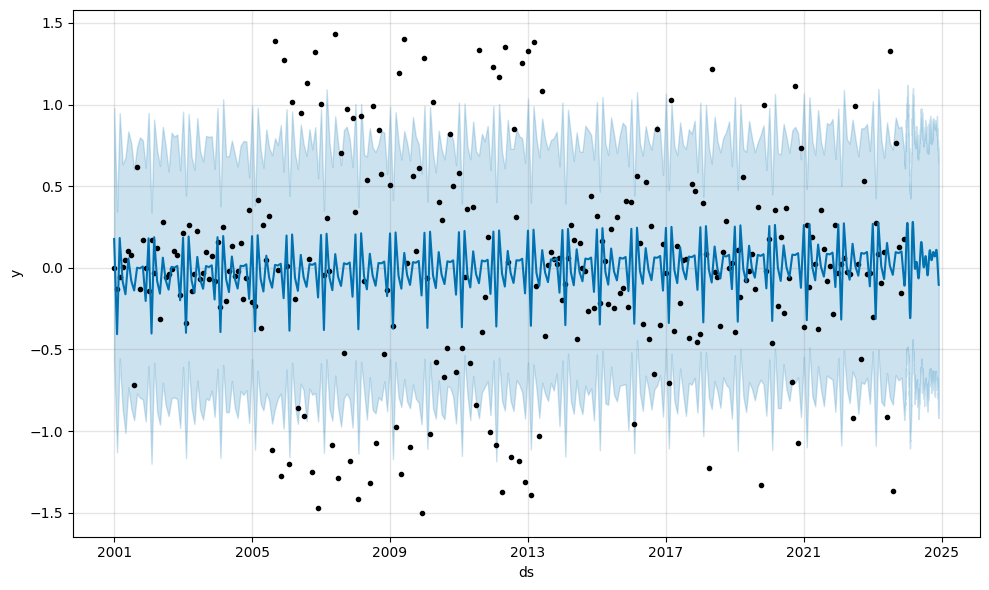

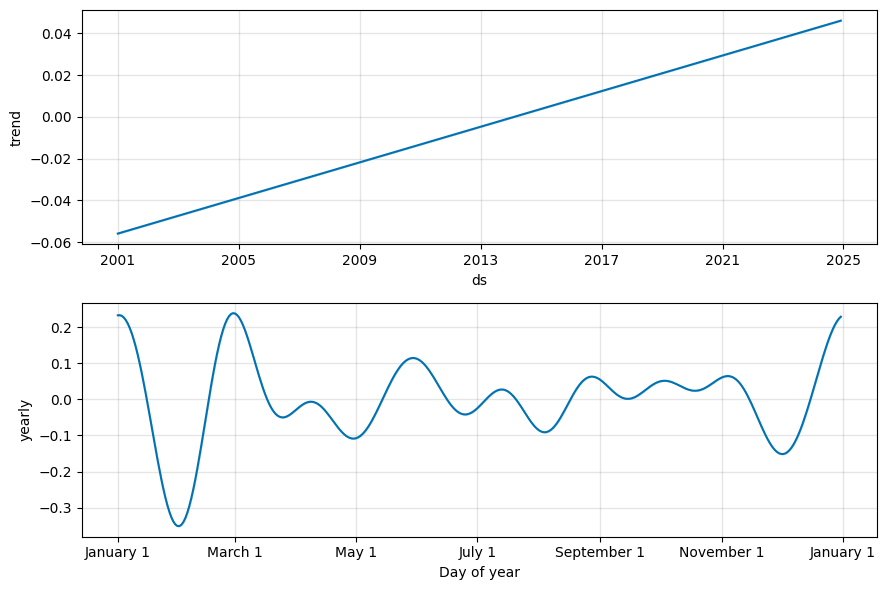

In [58]:
print("Modelo prophet ==================================================")
from prophet import Prophet

df_train = pd.DataFrame({
    "ds": train_data.index,
    "y": list(train_data)
})

print(df_train)

m = Prophet()
m.fit(df_train)

future = m.make_future_dataframe(periods=365)
future.tail()
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()
fig1 = m.plot(forecast)
fig2 = m.plot_components(forecast)

print("Modelo Holt-Winters ==================================================")
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model = ExponentialSmoothing(train_data, trend='add', seasonal='add', seasonal_periods=12)
fit = model.fit()

forecast_steps = 6  # Number of steps to forecast
predictions = fit.forecast(forecast_steps)

Modelo de Redes Neuronales ==================================================
RMSE en prueba: 0.3363
MAE en prueba: 0.2473


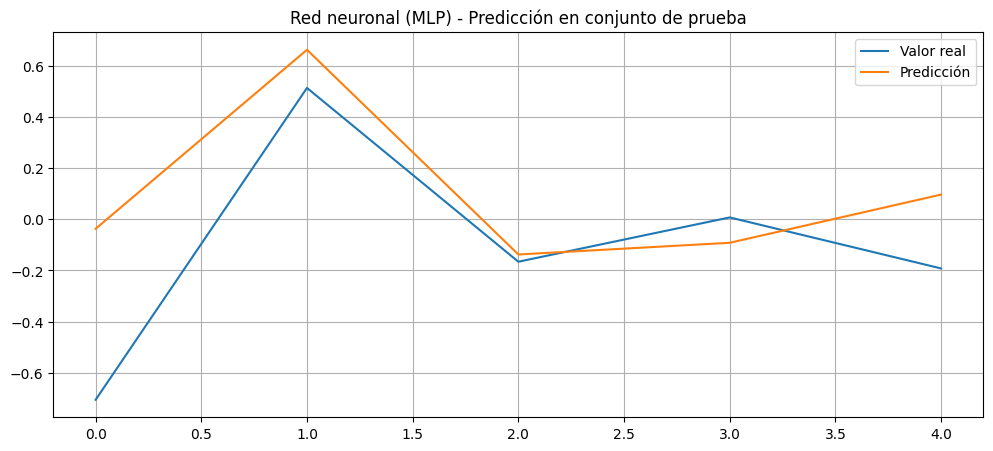

In [59]:
# lags para predecir siguientes valores
def ventanas(serie, n_lags):
    X, y = [], []
    for i in range(n_lags, len(serie)):
        X.append(serie[i - n_lags:i])
        y.append(serie[i])
    return np.array(X), np.array(y)

# Transformar serie a numpy
serie_total = np.concatenate([train_data.values, test_data.values])
n_lags = 5

# Crear sets con ventanas
X_all, y_all = ventanas(serie_total, n_lags)

# División entre entrenamiento y prueba
split_index = len(train_data) - n_lags
X_train, X_test = X_all[:split_index], X_all[split_index:]
y_train, y_test = y_all[:split_index], y_all[split_index:]

# Escalado de salida
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

# Entrenar red neuronal
mlp = MLPRegressor(hidden_layer_sizes=(100,), activation='relu',
                   solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train, y_train_scaled)

# Predicción y desescalado
y_pred_scaled = mlp.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Evaluación
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)

print("Modelo de Redes Neuronales ==================================================")
print(f"RMSE en prueba: {rmse:.4f}")
print(f"MAE en prueba: {mae:.4f}")

# Gráfico
plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Valor real")
plt.plot(y_pred, label="Predicción")
plt.title("Red neuronal (MLP) - Predicción en conjunto de prueba")
plt.legend()
plt.grid(True)
plt.show()


### Predicción

In [60]:
resultados_modelos = [
    ["ARIMA(0,1,1)", mean_squared_error(newDF["Original"], newDF["Model_0_1_1"], squared=False),
     mean_absolute_error(newDF["Original"], newDF["Model_0_1_1"])],
    ["ARIMA(1,1,1)", mean_squared_error(newDF["Original"], newDF["Model_1_1_1"], squared=False),
     mean_absolute_error(newDF["Original"], newDF["Model_1_1_1"])],
    ["ARIMA(2,1,0)", mean_squared_error(newDF["Original"], newDF["Model_2_1_0"], squared=False),
     mean_absolute_error(newDF["Original"], newDF["Model_2_1_0"])],
    ["ARIMA auto", mean_squared_error(newDF["Original"], newDF["Model_auto"], squared=False),
     mean_absolute_error(newDF["Original"], newDF["Model_auto"])],
    ["MLP", rmse, mae]
]

print(tabulate(resultados_modelos, headers=["Modelo", "RMSE", "MAE"], floatfmt=".4f", tablefmt="github"))

| Modelo       |   RMSE |    MAE |
|--------------|--------|--------|
| ARIMA(0,1,1) | 0.4084 | 0.3184 |
| ARIMA(1,1,1) | 0.3395 | 0.2678 |
| ARIMA(2,1,0) | 0.3995 | 0.3398 |
| ARIMA auto   | 0.2281 | 0.1947 |
| MLP          | 0.3363 | 0.2473 |


## Discusión

La serie de tiempo de precios fue afectada de forma grave por la pandemia, basta con hacer memoria para ver que los precios realmente no han regresado a como se encontraban anteriormente y todavía no se han regresado a la normalidad aún 5 años después desde que inició. Para las series de consumos e importaciones se puede ver un pico claro en los años de pandemia, en especial para la serie de consumo de diésel, sin embargo para la serie de importación de glp este pico se disfraza muy bien ya que esta serie es en extremo variable. Estas dos series siguen con una tendencia al alza en tiempos actuales, lo que nos permite decir que el mercado está prosperando a pesar del _contratiempo_ que tuvo por la pandemia.

Finalmente, la guerra de Rusia/Ucrania comenzó en el año 2014, Aunque se puede ver un pico en los consumos, reamente no afectó de forma significativa pues la tendencia se mantuvo al alzar y no se ve un gran cambio en las gráficas en las series de tiempo. Sin embargo, es posible que sus secuelas sí puedan afectar en un futuro por lo que no podemos confiarnos a que nos hemos librado ya que esta guerra sigue.
